# Домашнее задание

## Часть 1. Normalizing Flow. RealNVP

**(2 / 10 баллов)**

На лекции мы познакомились с методом *RealNVP*. Более того, в лекционном ноутбуке есть код, реализующий обучение данной модели, однако некоторые части кода пропущены. Ваша задача - дописать их и получить графики, схожие с графиками из лекционного ноутбука.

За теоретическими справками, пожалуйста, обращайтесь к лекции, либо к статье [realnvp](https://arxiv.org/abs/1605.08803)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import MultivariateNormal


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def make_moons_data(n_samples=2000, noise=0.06):
    x, _ = make_moons(n_samples=n_samples, noise=noise, random_state=SEED)
    x = x.astype(np.float32)

    x = x - x.mean(axis=0, keepdims=True)
    x = x / x.std(axis=0, keepdims=True)

    return torch.tensor(x, dtype=torch.float32)


class STNet(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class AffineCoupling(nn.Module):
    def __init__(self, mask, hidden_dim=128):
        super().__init__()
        # If mask = [1, 0]:
        #   x1 stays unchanged
        #   x2 transformed using x1
        self.register_buffer("mask", torch.tensor(mask, dtype=torch.float32))
        self.s_net = STNet(in_dim=2, hidden_dim=hidden_dim, out_dim=2)
        self.t_net = STNet(in_dim=2, hidden_dim=hidden_dim, out_dim=2)

    def forward(self, x):
        """
        y1 = x1
        y2 = x2 * exp(s(x1)) + t(x1)
        
        Returns:
            y, log_det
        """
        x_masked = x * self.mask

        s = self.s_net(x_masked) * (1 - self.mask)
        t = self.t_net(x_masked) * (1 - self.mask)

        # Ограничиваем scale для стабильности
        s = torch.tanh(s)

        y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)

        log_det = torch.sum(s, dim=1)

        return y, log_det

    def inverse(self, y):
        """
        z -> x
        Inverse transformation
        """
        y_masked = y * self.mask

        s = self.s_net(y_masked) * (1 - self.mask)
        t = self.t_net(y_masked) * (1 - self.mask)

        s = torch.tanh(s)

        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s)) # формула из ноутбука лекции
        return x


class RealNVP2D(nn.Module):
    def __init__(self, n_coupling_layers=8, hidden_dim=128):
        super().__init__()

        layers = []
        for i in range(n_coupling_layers):
            if i % 2 == 0:
                mask = [1.0, 0.0]
            else:
                mask = [0.0, 1.0]
            layers.append(AffineCoupling(mask=mask, hidden_dim=hidden_dim))

        self.layers = nn.ModuleList(layers)

        self.base_dist = MultivariateNormal( # распределение
            loc=torch.zeros(2, device=device),
            covariance_matrix=torch.eye(2, device=device),
        )

    def forward(self, x):
        """
        Data x -> latent z
        Returns:
            z, sum_log_det
        """
        log_det_sum = torch.zeros(x.shape[0], device=x.device)
        z = x

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        return z, log_det_sum

    def inverse(self, z):
        """
        Latent z -> data x
        """
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def log_prob(self, x):
        z, log_det_sum = self.forward(x)

        base_log_prob = self.base_dist.log_prob(z)

        log_prob = base_log_prob + log_det_sum

        return log_prob

    @torch.no_grad()
    def sample(self, n_samples):
        z = self.base_dist.sample((n_samples,))
        x = self.inverse(z)
        return x

Epoch    1 | NLL = 3.186412
Epoch  100 | NLL = 2.114232
Epoch  200 | NLL = 1.914322
Epoch  300 | NLL = 1.666016
Epoch  400 | NLL = 1.819438
Epoch  500 | NLL = 1.655387
Epoch  600 | NLL = 1.688758
Epoch  700 | NLL = 1.689538
Epoch  800 | NLL = 1.731424
Epoch  900 | NLL = 1.650535
Epoch 1000 | NLL = 1.738267
Epoch 1100 | NLL = 1.664291
Epoch 1200 | NLL = 1.662562
Epoch 1300 | NLL = 1.604843
Epoch 1400 | NLL = 1.642161
Epoch 1500 | NLL = 1.682763
Epoch 1600 | NLL = 1.717694
Epoch 1700 | NLL = 1.656873
Epoch 1800 | NLL = 1.689358
Epoch 1900 | NLL = 1.564628
Epoch 2000 | NLL = 1.715149


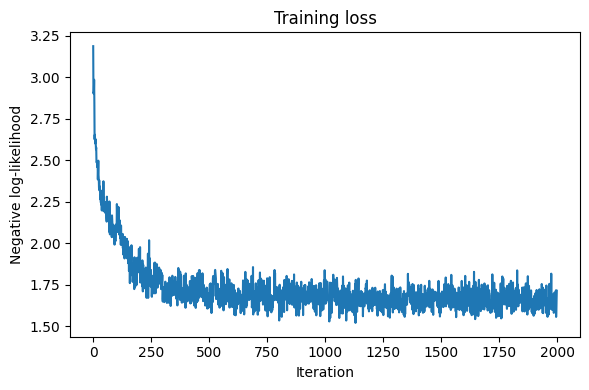

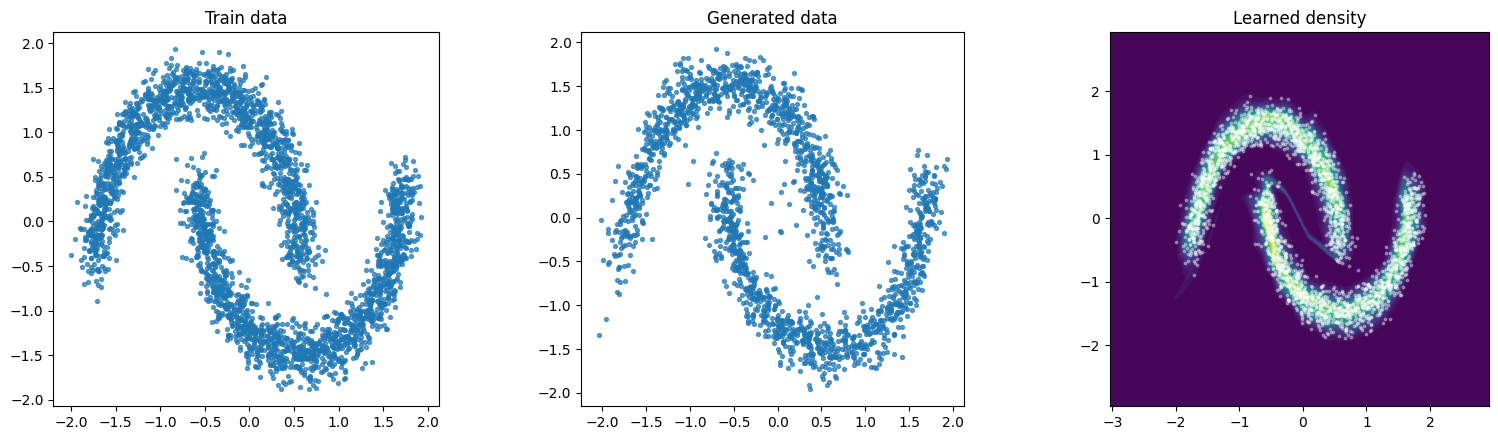

In [3]:
@torch.no_grad()
def plot_results(model, train_data, n_generated=2000, grid_points=300):
    model.eval()

    train_np = train_data.cpu().numpy()
    generated = model.sample(n_generated).cpu().numpy()

    all_x = np.concatenate([train_np[:, 0], generated[:, 0]])
    all_y = np.concatenate([train_np[:, 1], generated[:, 1]])

    x_min, x_max = all_x.min() - 1.0, all_x.max() + 1.0
    y_min, y_max = all_y.min() - 1.0, all_y.max() + 1.0

    xs = np.linspace(x_min, x_max, grid_points)
    ys = np.linspace(y_min, y_max, grid_points)
    xx, yy = np.meshgrid(xs, ys)

    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    grid_t = torch.tensor(grid, device=device)

    log_prob = model.log_prob(grid_t).cpu().numpy()
    density = np.exp(log_prob).reshape(xx.shape)

    _, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(train_np[:, 0], train_np[:, 1], s=8, alpha=0.7)
    axes[0].set_title("Train data")
    axes[0].set_aspect("equal")

    axes[1].scatter(generated[:, 0], generated[:, 1], s=8, alpha=0.7)
    axes[1].set_title("Generated data")
    axes[1].set_aspect("equal")

    axes[2].contourf(xx, yy, density, levels=40)
    axes[2].scatter(train_np[:, 0], train_np[:, 1], s=3, c="white", alpha=0.35)
    axes[2].set_title("Learned density")
    axes[2].set_aspect("equal")

    plt.tight_layout()
    plt.show()


def train_real_nvp():
    n_samples = 3000
    noise = 0.08
    batch_size = 256
    n_epochs = 2000
    lr = 1e-3
    log_every = 100

    train_data = make_moons_data(n_samples=n_samples, noise=noise).to(device)

    model = RealNVP2D(
        n_coupling_layers=10,
        hidden_dim=128,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(1, n_epochs + 1):
        model.train()

        indices = torch.randint(0, train_data.shape[0], (batch_size,), device=device)
        batch = train_data[indices]

        log_prob = model.log_prob(batch)
        loss = -log_prob.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | NLL = {loss.item():.6f}")

    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.title("Training loss")
    plt.xlabel("Iteration")
    plt.ylabel("Negative log-likelihood")
    plt.tight_layout()
    plt.show()

    plot_results(model, train_data)


train_real_nvp()

## Часть 2. ImageGPT

**(8 / 10 баллов)**

В данной части вам предстоит самостоятельно реализовать модель ImageGPT ([статья](https://cdn.openai.com/papers/Generative_Pretraining_from_Pixels_V2.pdf) а также [блогпост](https://openai.com/index/image-gpt/))

Обучаться мы будем на датасете MNIST.

Ваша задача состоит в следующем:

1. Завершить код с архитектурой модели *(4 балла)*
2. Самостоятельно реализовать код обучения модели *(4 балла)*
   1. Train loop
   2. Визуализация лосса
   3. Визуализация результатов генерации

---

In [4]:
# код с датасетом подготовили для вас
# попробуйте его визуализировать, понять, что у вас за данные
import torch
import torchvision
from torchvision.datasets import MNIST


root = "./.data"
train_dataset = MNIST(root=root, train=True, download=True)
test_dataset = MNIST(root=root, train=False, download=True)
    
transform = torchvision.transforms.Resize((32, 32))
train_data = torch.stack([transform(img.unsqueeze(0)) for img in train_dataset.data]).numpy().transpose(0, 2, 3, 1)
test_data = torch.stack([transform(img.unsqueeze(0)) for img in test_dataset.data]).numpy().transpose(0, 2, 3, 1)

train_data = (train_data > 128).astype("int64")
test_data = (test_data > 128).astype("int64")

train_data = np.transpose(train_data, (0, 3, 1, 2))
test_data = np.transpose(test_data, (0, 3, 1, 2))

In [5]:
class MultiheadAttention(nn.MultiheadAttention):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        super().__init__(embed_dim, num_heads)

    def get_attention_mask(self, x: torch.Tensor) -> torch.Tensor:
        # define attention mask, it should contain
        # - zeros under and on the main diagonal
        # - minus Inf above the main diagonal

        seq_len = x.size(0)

        mask = torch.full(
            (seq_len, seq_len),
            float("-inf"),
            device=x.device,
            dtype=x.dtype,
        )
        
        return torch.triu(mask, diagonal=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_mask = self.get_attention_mask(x)
        return super().forward(x, x, x, attn_mask=attn_mask, need_weights=False)[0]


def test_attention_mask() -> None:
    x = torch.zeros(2, 4, 16)  # (pixel_num, batch_size, emb_dim)
    mask = np.array([[0.0, -np.inf], [0.0, 0.0]])
    layer = MultiheadAttention(16, 8)
    attention_mask = layer.get_attention_mask(x)
    assert attention_mask.size() == (x.size(0), x.size(0))
    assert np.allclose(attention_mask.numpy(), mask)
    out = layer(x)
    assert x.size() == out.size()


test_attention_mask()

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        """
        :param embed_dim: dimension of embedding space
        :param num_heads: number of attention heads
        """
        super().__init__()
        assert embed_dim % num_heads == 0

        # your code
        # define multihead attention
        # define LayerNorm 
        # define MLP - 2 linear layers with ReLU

        self.attn = MultiheadAttention(embed_dim, num_heads)

        self.ln_1 = nn.LayerNorm(embed_dim)
        self.ln_2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

def test_decoder_block() -> None:
    block = DecoderBlock(embed_dim=12, num_heads=4)
    x = torch.zeros(4, 28, 12)
    assert x.shape == block(x).shape


test_decoder_block()


In [9]:
class ImageGPT(nn.Module):
    def __init__(
        self, input_shape: tuple[int, int], embed_dim: int, num_heads: int, num_layers: int
    ) -> None:
        super().__init__()

        self.embed_dim = embed_dim
        self.input_shape = input_shape
        self.criterion = nn.BCEWithLogitsLoss() # видимо для чёрно-белых картинок

        self.length = input_shape[0] * input_shape[1] # всего пикселей

        # "start of sequence" token (we initialize it from Normal distribution)
        self.sos = torch.nn.Parameter(torch.zeros(embed_dim))
        nn.init.normal_(self.sos)

        # 1) define token_embeddings
        # 2) define position_embeddings (they will be learnable)
        # (use torch.nn.Embedding)

        self.token_embeddings = nn.Embedding(2, embed_dim) # 2 так как бинарные пиксели
        self.position_embeddings = nn.Embedding(self.length, embed_dim)

        self.layers = nn.ModuleList()
        # 1) add decoder blocks to self.layers list
        # 2) define last LayerNorm
        # 3) define final Linear layer (without bias)
        
        for _ in range(num_layers):
            self.layers.append(DecoderBlock(embed_dim, num_heads))

        self.ln_f = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, 1, bias=False)

    def add_sos_token(self, embeddings: torch.Tensor) -> torch.Tensor:
        batch_size = embeddings.size(1)
        # prepend sos (start of sequence) token
        # 1) repeat sos token batch_size times (make it of size (1, batch_size, emd_size))
        # 2) drop last embedding from embeddings
        # 3) concat repeated sos token to embeddings (after dropping)

        # sos: (embed_dim,) -> (1, 1, embed_dim) -> (1, batch_size, embed_dim)
        sos = self.sos.view(1, 1, self.embed_dim).repeat(1, batch_size, 1)

        embeddings = embeddings[:-1]

        embeddings = torch.cat([sos, embeddings], dim=0)

        return embeddings

    def add_pos_embeddings(self, embeddings: torch.Tensor) -> torch.Tensor:
        length = embeddings.size(0)
        # add positional embeddings
        # 1) define tensor with positions (just torch.arange) of size (length, 1)
        # 2) add position embeddings to initial embeddings

        positions = torch.arange(length, device=embeddings.device).view(length, 1)
        embeddings = embeddings + self.position_embeddings(positions)

        return embeddings

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.long()
        x = x.reshape(x.size(0), -1)  # (batch_size, length)
        x = x.permute(1, 0)

        embeddings = self.token_embeddings(x)  # (length, batch_size, emb_size)
        embeddings = self.add_sos_token(embeddings)
        embeddings = self.add_pos_embeddings(embeddings)

        # 1) apply all decoder layers
        # 2) apply final LayerNorm and Linear layer

        for layer in self.layers:
            embeddings = layer(embeddings)

        embeddings = self.ln_f(embeddings)
        logits = self.head(embeddings)  # (length, batch_size, 1)

        return logits.permute(1, 0, 2)  # (length, batch_size, emb_size) -> (batch_size, length, emb_size)

    def loss(self, x: torch.Tensor) -> dict:
        logits = self(x)
        loss = self.criterion(logits.reshape(-1), x.reshape(-1).float())
        return {"total_loss": loss}

    @torch.no_grad()
    def sample(self, n_samples: int) -> np.ndarray:
        # hint: You can use PixelCNN sample from lecture for inspiration
        # 1. You sample not an image (2d) but a sequence (1d) that will be reshaped in the end
        # 2. Instead multinomial you can use Bernoulli distribution

        # спасибо за hint, в лекции оно не реализовано
        
        device = self.sos.device
        height, width = self.input_shape
        length = height * width

        samples = torch.zeros(n_samples, length, device=device, dtype=torch.long)

        for i in range(length):
            logits = self(samples)              # (n_samples, length, 1)
            probs = torch.sigmoid(logits[:, i, 0])

            samples[:, i] = torch.bernoulli(probs).long()

        samples = samples.reshape(n_samples, 1, height, width)

        return samples


def test_image_gpt() -> None:
    image_gpt = ImageGPT(input_shape=(2, 2), embed_dim=12, num_heads=4, num_layers=2)
    x = torch.LongTensor([[0, 1, 0, 0], [0, 1, 1, 1]])
    assert image_gpt(x).shape == torch.Size([2, 4, 1])
    assert image_gpt.loss(x)["total_loss"].requires_grad == True
    assert image_gpt.sample(1).shape == torch.Size([1, 1, 2, 2])
    img = torch.randint(2, size=(1, 1, 2, 2))


test_image_gpt()

In [22]:
# место для обучения, экспериментов и визуализации результатов

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from datasets import load_dataset

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

CATEGORY = "cat"      # можно заменить: "house", "tree", "car", "bicycle", "fish", ...
IMAGE_SIZE = 16       # 16x16 для быстрого теста
N_TRAIN = 20_000      # можно уменьшить до 2000 для проверки
N_VAL = 2_000

BATCH_SIZE = 64
NUM_EPOCHS = 10
LR = 3e-4

EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4

cpu


In [17]:
# ============================================================
# 3. QuickDraw binary dataset
# ============================================================

class QuickDrawBinaryDataset(Dataset):
    def __init__(
        self,
        category: str | None = "cat",
        split: str = "train",
        image_size: int = 16,
        n_samples: int | None = None,
        threshold: float = 0.5,
        invert: bool = True,
        verbose: bool = True,
    ) -> None:
        """
        Загружает Xenova/quickdraw-small.

        Возвращает:
            x: torch.LongTensor shape (1, image_size, image_size), values 0/1

        Обычно для рисованных линий удобно:
            фон = 0
            линия = 1

        Если после визуализации линии черные на белом фоне,
        поменяй invert=True/False.
        """
        self.category = category
        self.image_size = image_size
        self.threshold = threshold
        self.invert = invert

        ds = load_dataset("Xenova/quickdraw-small", split=split)

        if verbose:
            print("Loaded dataset:")
            print(ds)
            print("Columns:", ds.column_names)
            print("Features:", ds.features)

        label_field = None
        for candidate in ["word", "category", "label", "class"]:
            if candidate in ds.column_names:
                label_field = candidate
                break

        if verbose:
            print("Detected label field:", label_field)

        if category is not None and label_field is not None:
            feature = ds.features[label_field]

            # Случай ClassLabel
            if hasattr(feature, "names") and feature.names is not None:
                names = feature.names

                if verbose:
                    print("First categories:", names[:30])

                if category not in names:
                    raise ValueError(
                        f"Category '{category}' not found. "
                        f"Available examples: {names[:50]}"
                    )

                category_id = names.index(category)

                ds = ds.filter(
                    lambda example: example[label_field] == category_id
                )

            # Случай строковых label
            else:
                if verbose:
                    preview = ds.select(range(min(1000, len(ds))))
                    values = set(preview[label_field])
                    print("Label preview:", list(values)[:30])

                ds = ds.filter(
                    lambda example: example[label_field] == category
                )

        elif category is not None and label_field is None:
            print(
                "WARNING: no label/category field found. "
                "Using all categories mixed."
            )

        if n_samples is not None:
            n_samples = min(n_samples, len(ds))
            ds = ds.select(range(n_samples))

        self.ds = ds

        if verbose:
            print("Final dataset size:", len(self.ds))
            if len(self.ds) > 0:
                print("First item keys:", self.ds[0].keys())

    def __len__(self) -> int:
        return len(self.ds)

    def _get_image_from_item(self, item):
        for key in ["image", "img", "drawing"]:
            if key in item:
                return item[key]

        raise KeyError(
            f"Cannot find image field. Available keys: {item.keys()}"
        )

    def __getitem__(self, idx: int) -> torch.Tensor:
        item = self.ds[idx]
        img = self._get_image_from_item(item)

        if isinstance(img, Image.Image):
            img = img.convert("L")
        else:
            img = Image.fromarray(np.array(img)).convert("L")

        img = img.resize(
            (self.image_size, self.image_size),
            Image.BILINEAR,
        )

        arr = np.array(img).astype("float32") / 255.0

        if self.invert:
            arr = 1.0 - arr

        arr = (arr > self.threshold).astype("int64")

        x = torch.from_numpy(arr).unsqueeze(0)
        return x


In [18]:
# ============================================================
# 4. Visualization utils
# ============================================================

def show_images(
    images: torch.Tensor,
    n: int | None = None,
    title: str = "",
    figsize_scale: float = 2.0,
) -> None:
    """
    images: Tensor shape (B, 1, H, W) или (B, H, W)
    """
    if isinstance(images, np.ndarray):
        images = torch.from_numpy(images)

    images = images.detach().cpu()

    if images.ndim == 3:
        images = images.unsqueeze(1)

    if n is None:
        n = images.size(0)

    n = min(n, images.size(0))

    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale, rows * figsize_scale),
    )

    axes = np.array(axes).reshape(-1)

    for i in range(n):
        axes[i].imshow(
            images[i, 0],
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_real_samples(dataset: Dataset, n: int = 25, title: str = "Real") -> None:
    images = torch.stack([dataset[i] for i in range(n)])
    show_images(images, n=n, title=title)


@torch.no_grad()
def show_generated_samples(
    model: ImageGPT,
    n_samples: int = 25,
    title: str = "Generated",
) -> torch.Tensor:
    model.eval()
    samples = model.sample(n_samples)
    show_images(samples, n=n_samples, title=title)
    return samples.detach().cpu()


@torch.no_grad()
def compare_real_generated(
    model: ImageGPT,
    dataset: Dataset,
    n: int = 10,
    title: str = "Real vs generated",
) -> None:
    model.eval()

    real = torch.stack([dataset[i] for i in range(n)]).cpu()

    generated = model.sample(n)
    if isinstance(generated, np.ndarray):
        generated = torch.from_numpy(generated)
    generated = generated.detach().cpu()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

    for i in range(n):
        axes[0, i].imshow(real[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[0, i].set_title("real")

        axes[1, i].imshow(generated[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
        axes[1, i].set_title("gen")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_losses(
    train_losses: list[float],
    val_losses: list[float] | None = None,
    title: str = "Loss",
) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, marker="o", label="train")

    if val_losses is not None:
        plt.plot(val_losses, marker="o", label="val")

    plt.xlabel("Epoch")
    plt.ylabel("BCEWithLogitsLoss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


In [19]:
# ============================================================
# 5. Train / eval functions
# ============================================================

def train_one_epoch(
    model: ImageGPT,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    grad_clip: float | None = 1.0,
) -> float:
    model.train()

    losses = []

    pbar = tqdm(loader, desc="train", leave=False)

    for batch in pbar:
        batch = batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        loss = model.loss(batch)["total_loss"]

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=grad_clip,
            )

        optimizer.step()

        losses.append(loss.item())
        pbar.set_postfix(loss=float(np.mean(losses)))

    return float(np.mean(losses))


@torch.no_grad()
def evaluate(
    model: ImageGPT,
    loader: DataLoader,
    device: torch.device,
) -> float:
    model.eval()

    losses = []

    for batch in tqdm(loader, desc="eval", leave=False):
        batch = batch.to(device)
        loss = model.loss(batch)["total_loss"]
        losses.append(loss.item())

    return float(np.mean(losses))


In [ ]:
# ============================================================
# 6. Single experiment runner
# ============================================================

def run_experiment(
    category: str | None = "cat",
    image_size: int = 16,
    n_samples: int = 10_000,
    val_fraction: float = 0.1,
    batch_size: int = 64,
    num_epochs: int = 10,
    embed_dim: int = 128,
    num_heads: int = 4,
    num_layers: int = 4,
    lr: float = 3e-4,
    threshold: float = 0.5,
    invert: bool = True,
    show_every: int = 2,
    num_workers: int = 2,
) -> dict:
    print("=" * 80)
    print("Experiment")
    print("category:", category)
    print("image_size:", image_size)
    print("n_samples:", n_samples)
    print("embed_dim:", embed_dim)
    print("num_heads:", num_heads)
    print("num_layers:", num_layers)
    print("=" * 80)

    full_dataset = QuickDrawBinaryDataset(
        category=category,
        split="train",
        image_size=image_size,
        n_samples=n_samples,
        threshold=threshold,
        invert=invert,
        verbose=True,
    )

    if len(full_dataset) == 0:
        raise RuntimeError("Dataset is empty. Check category name/filtering.")

    show_real_samples(
        full_dataset,
        n=min(25, len(full_dataset)),
        title=f"Real QuickDraw samples: {category}",
    )

    val_size = int(len(full_dataset) * val_fraction)
    train_size = len(full_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    model = ImageGPT(
        input_shape=(image_size, image_size),
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4,
    )

    train_losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            grad_clip=1.0,
        )

        val_loss = evaluate(
            model=model,
            loader=val_loader,
            device=device,
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"epoch {epoch}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}"
        )

        if epoch == 1 or epoch % show_every == 0:
            show_generated_samples(
                model,
                n_samples=25,
                title=f"Generated: {category}, epoch {epoch}",
            )

    plot_losses(
        train_losses,
        val_losses,
        title=f"Loss: QuickDraw {category}",
    )

    compare_real_generated(
        model,
        full_dataset,
        n=10,
        title=f"QuickDraw {category}: real vs generated",
    )

    final_samples = show_generated_samples(
        model,
        n_samples=25,
        title=f"Final generated samples: {category}",
    )

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "dataset": full_dataset,
        "final_samples": final_samples,
    }


Experiment
category: cat
image_size: 8
n_samples: 1000
embed_dim: 64
num_heads: 4
num_layers: 2
Loaded dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 4500000
})
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle', 'binoculars', 'bird', 'birthday cake', 'blackberry', 'blueberry', 'book', 'boomerang', 'bottlecap', 'bowtie', 'bracelet', 'brain', 'bread', 'bridge', 'broccoli', 'broom', 'bucket', 'bulldozer', 'bus', 'bush', 'butterfly', 'cactus', 'cake', 'calculator', 'calendar', 'camel', 'camera', 'camouflage', 'campfire', 'candle', 'cannon', 'canoe', 'car', 'carrot', 'castle', 'cat', 'ceiling fan', 'cel

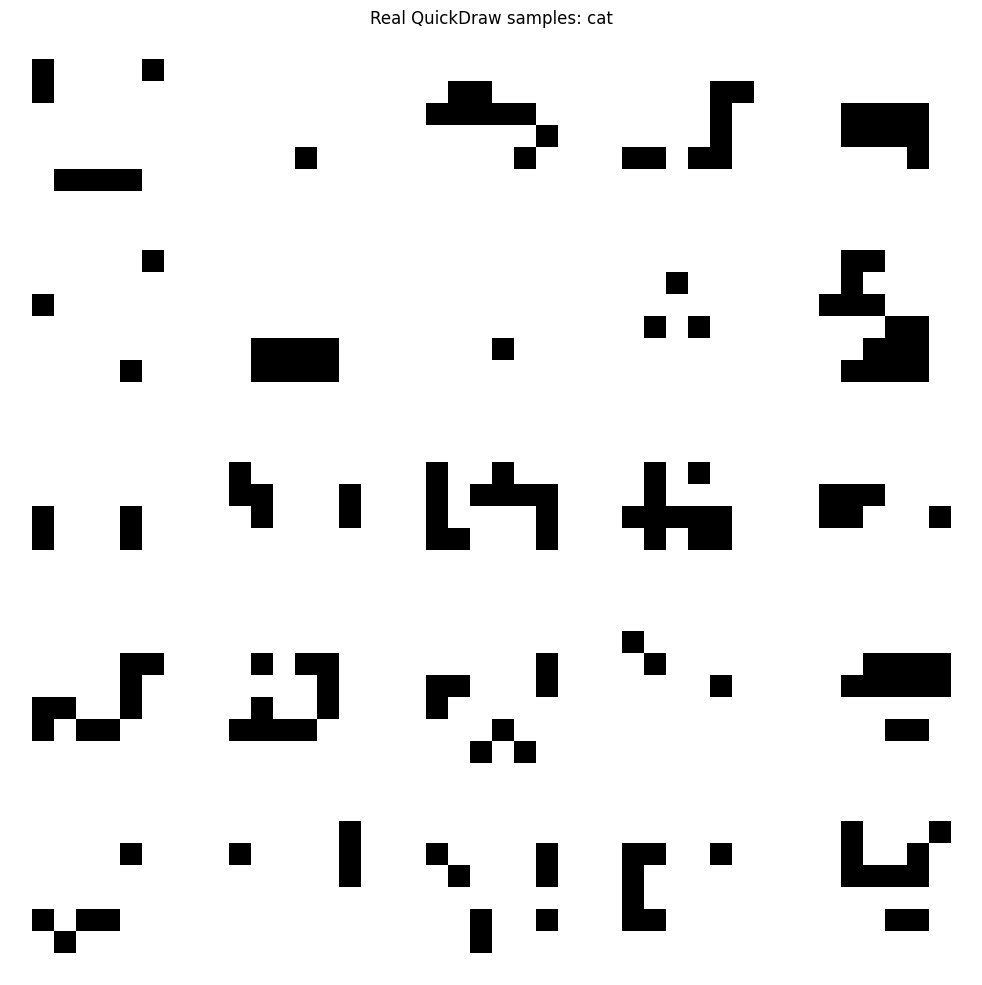


Epoch 1/2


train:   0%|          | 0/14 [00:00<?, ?it/s]

eval:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 1: train_loss=0.4717, val_loss=0.3341


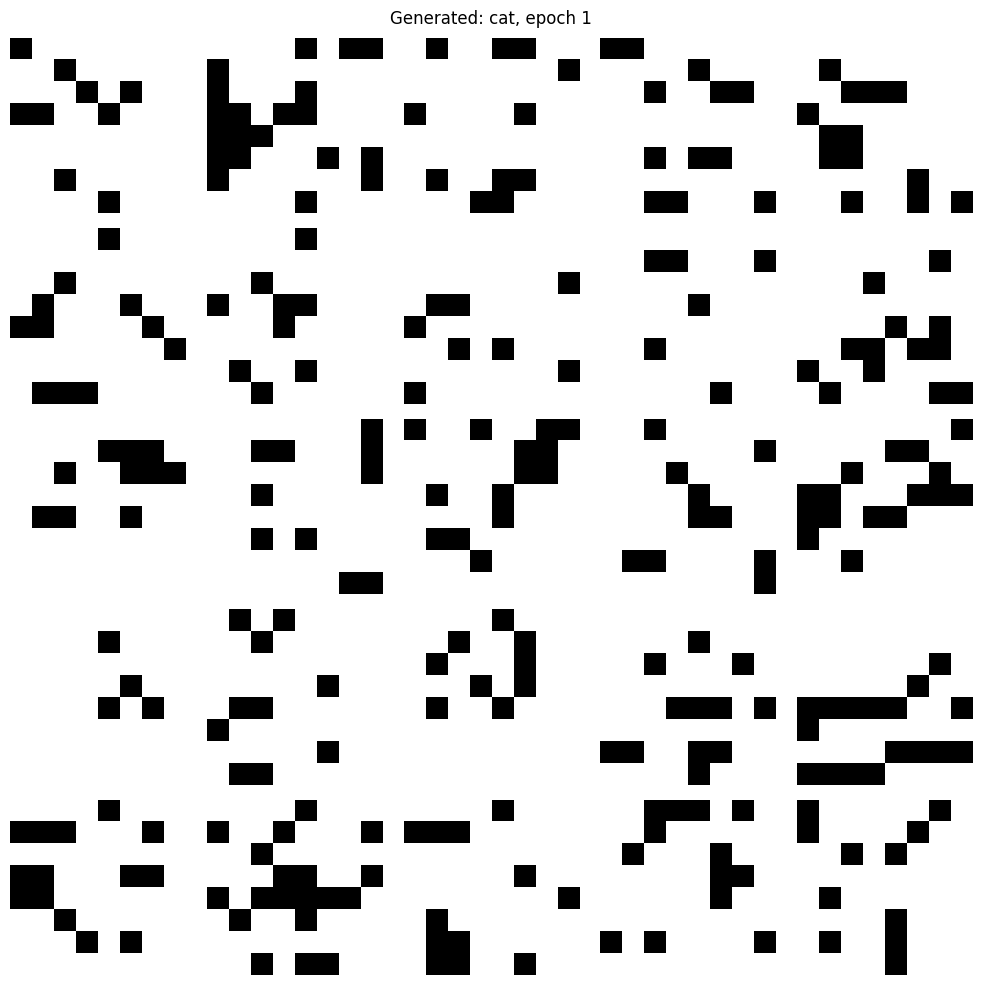


Epoch 2/2


train:   0%|          | 0/14 [00:00<?, ?it/s]

eval:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 2: train_loss=0.3267, val_loss=0.3088


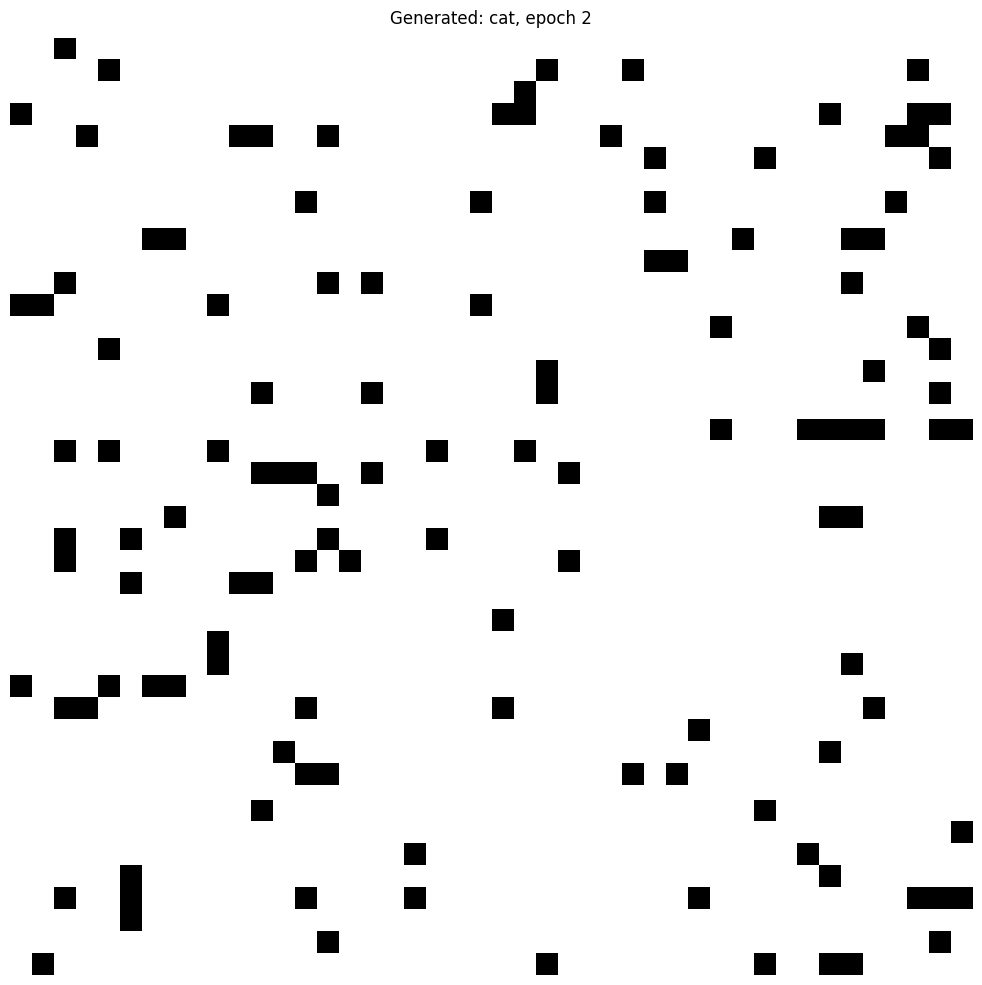

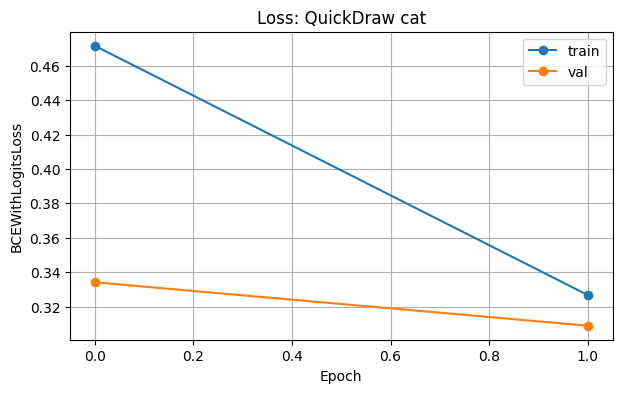

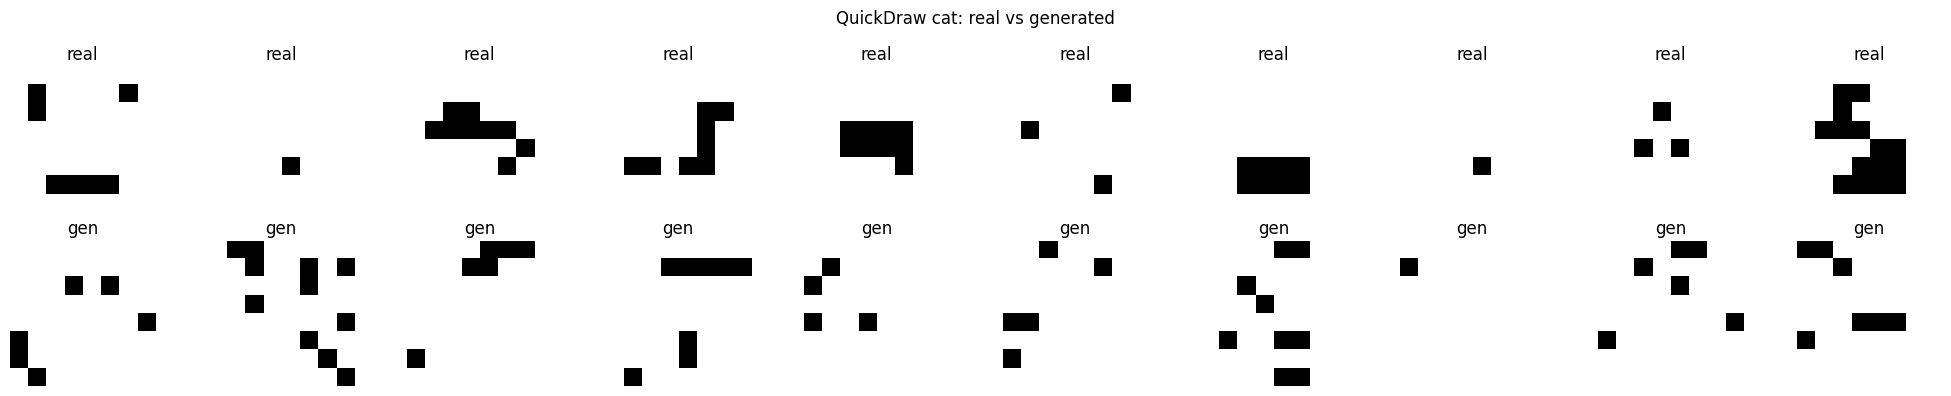

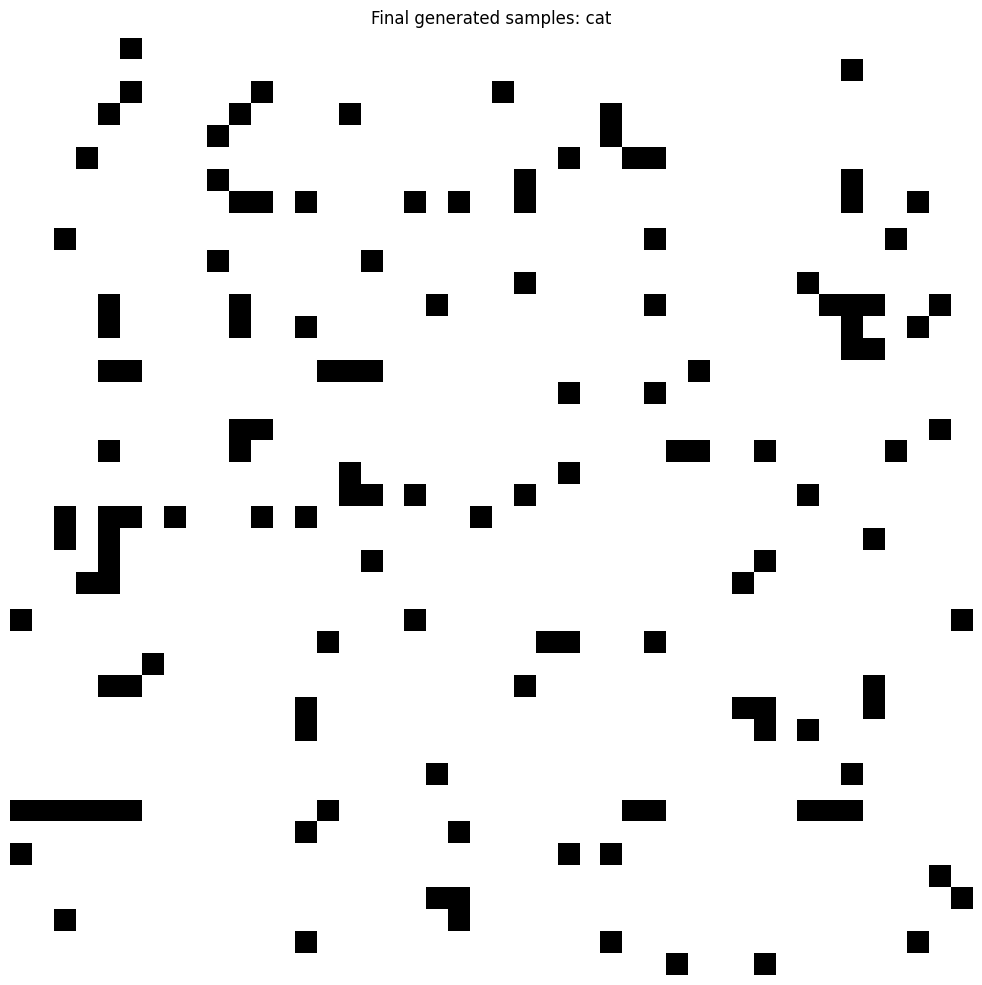

In [ ]:
# ============================================================
# 7. Fast smoke test
# ============================================================

# Если хочешь сначала быстро проверить, что все запускается:
# image_size=8, маленькая модель, мало данных.

smoke_result = run_experiment(
    category="cat",       # если фильтрация не сработает, попробуй category=None
    image_size=8,
    n_samples=1000,
    batch_size=64,
    num_epochs=2,
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    lr=3e-4,
    threshold=0.5,
    invert=True,
    show_every=1,
    num_workers=0,
)


Experiment
category: cat
image_size: 16
n_samples: 10000
embed_dim: 128
num_heads: 4
num_layers: 4
Loaded dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 4500000
})
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle', 'binoculars', 'bird', 'birthday cake', 'blackberry', 'blueberry', 'book', 'boomerang', 'bottlecap', 'bowtie', 'bracelet', 'brain', 'bread', 'bridge', 'broccoli', 'broom', 'bucket', 'bulldozer', 'bus', 'bush', 'butterfly', 'cactus', 'cake', 'calculator', 'calendar', 'camel', 'camera', 'camouflage', 'campfire', 'candle', 'cannon', 'canoe', 'car', 'carrot', 'castle', 'cat', 'ceiling fan', '

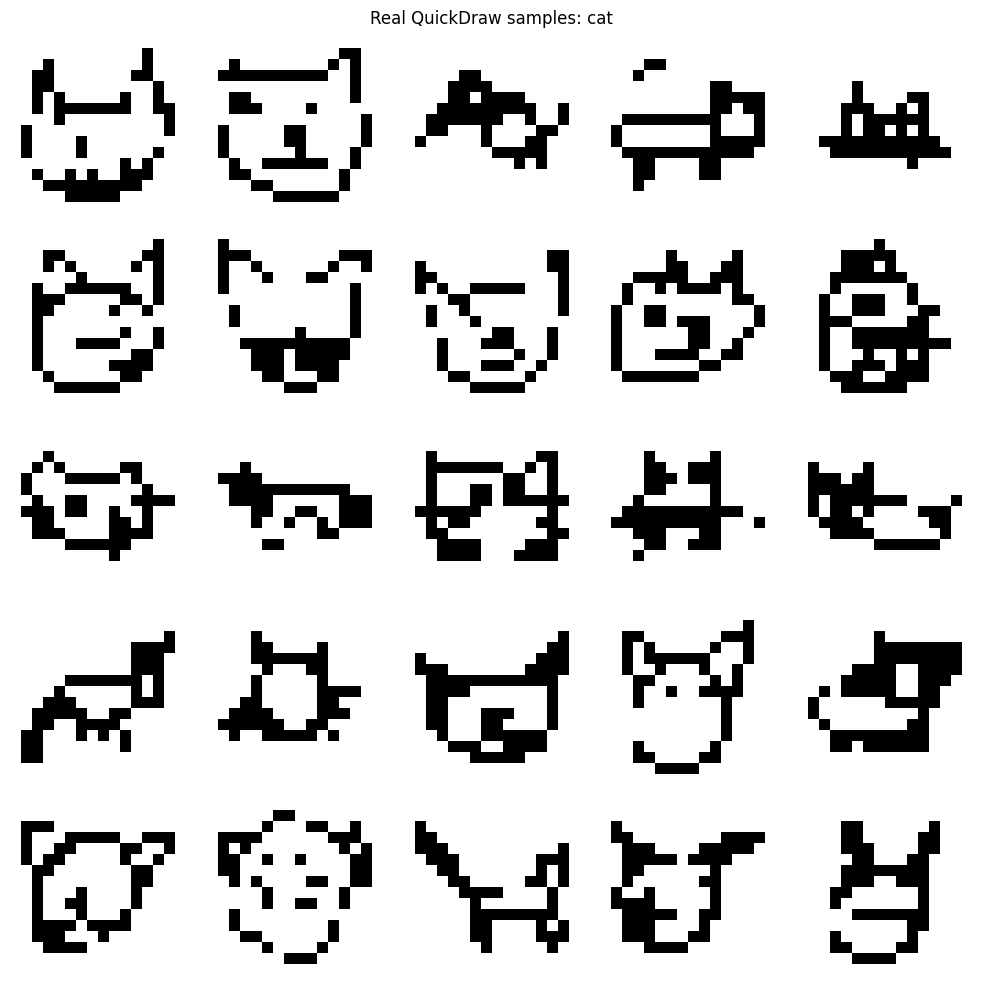


Epoch 1/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 1: train_loss=0.3842, val_loss=0.3427


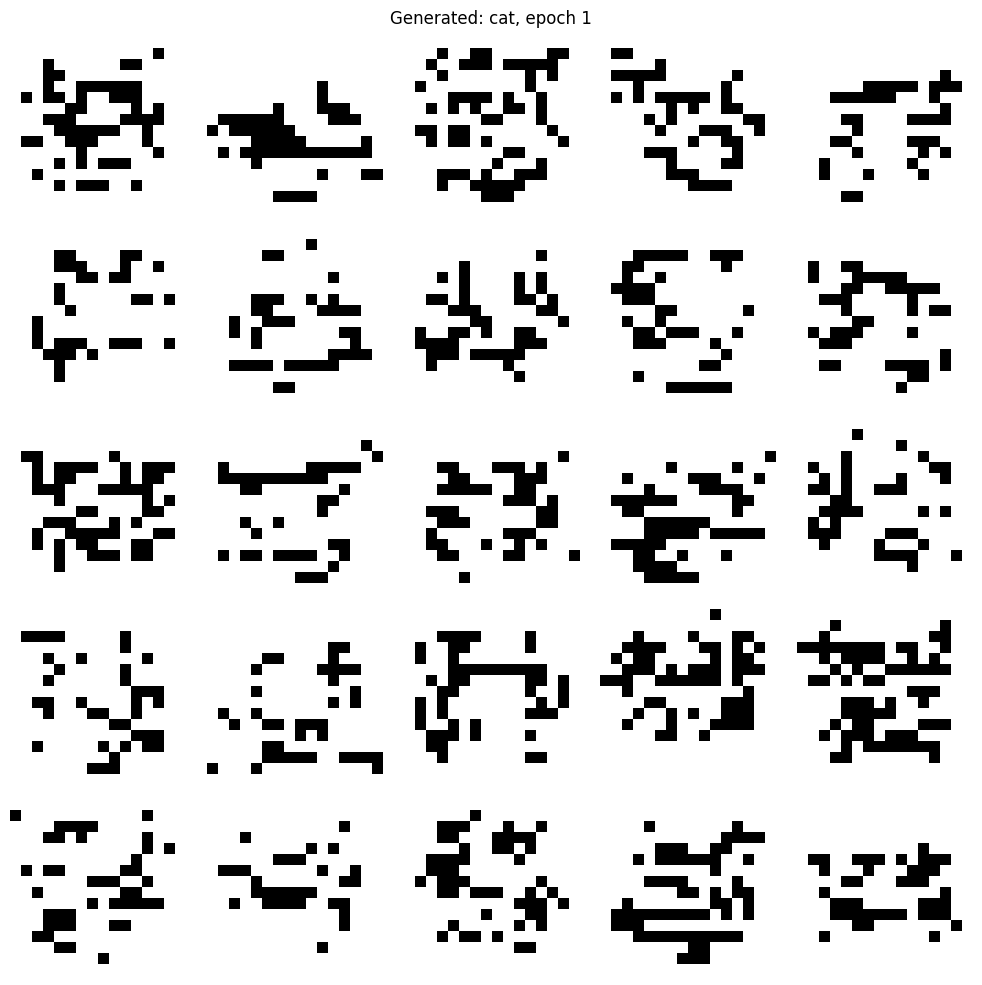


Epoch 2/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 2: train_loss=0.3331, val_loss=0.3236


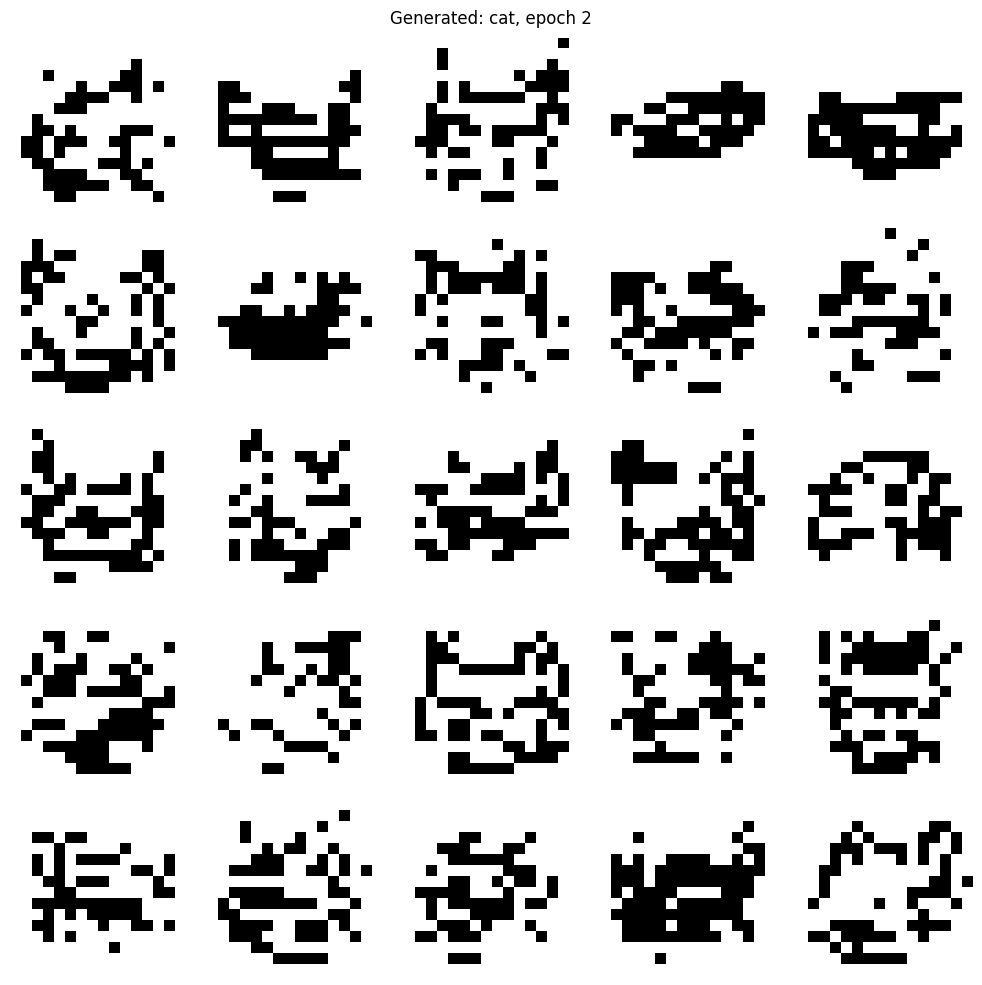


Epoch 3/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 3: train_loss=0.3167, val_loss=0.3078

Epoch 4/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 4: train_loss=0.3049, val_loss=0.2991


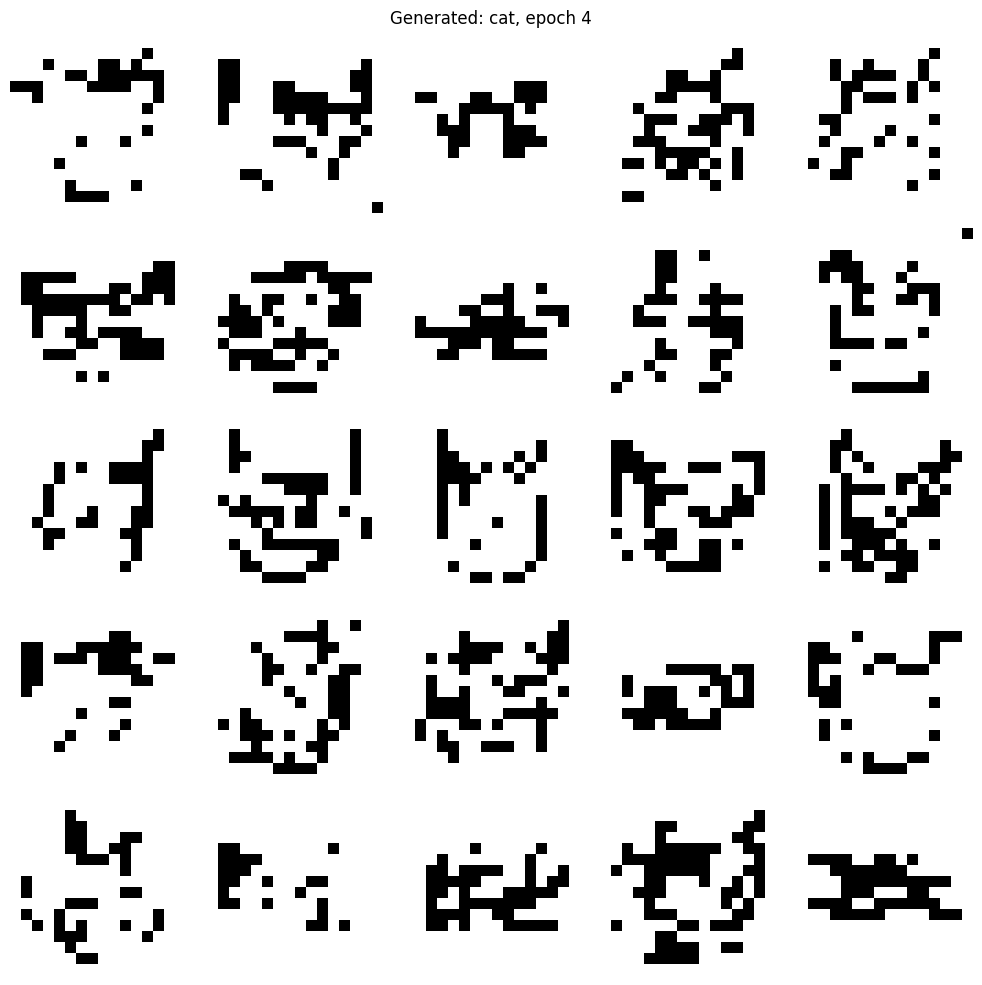


Epoch 5/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 5: train_loss=0.2973, val_loss=0.2936

Epoch 6/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 6: train_loss=0.2922, val_loss=0.2896


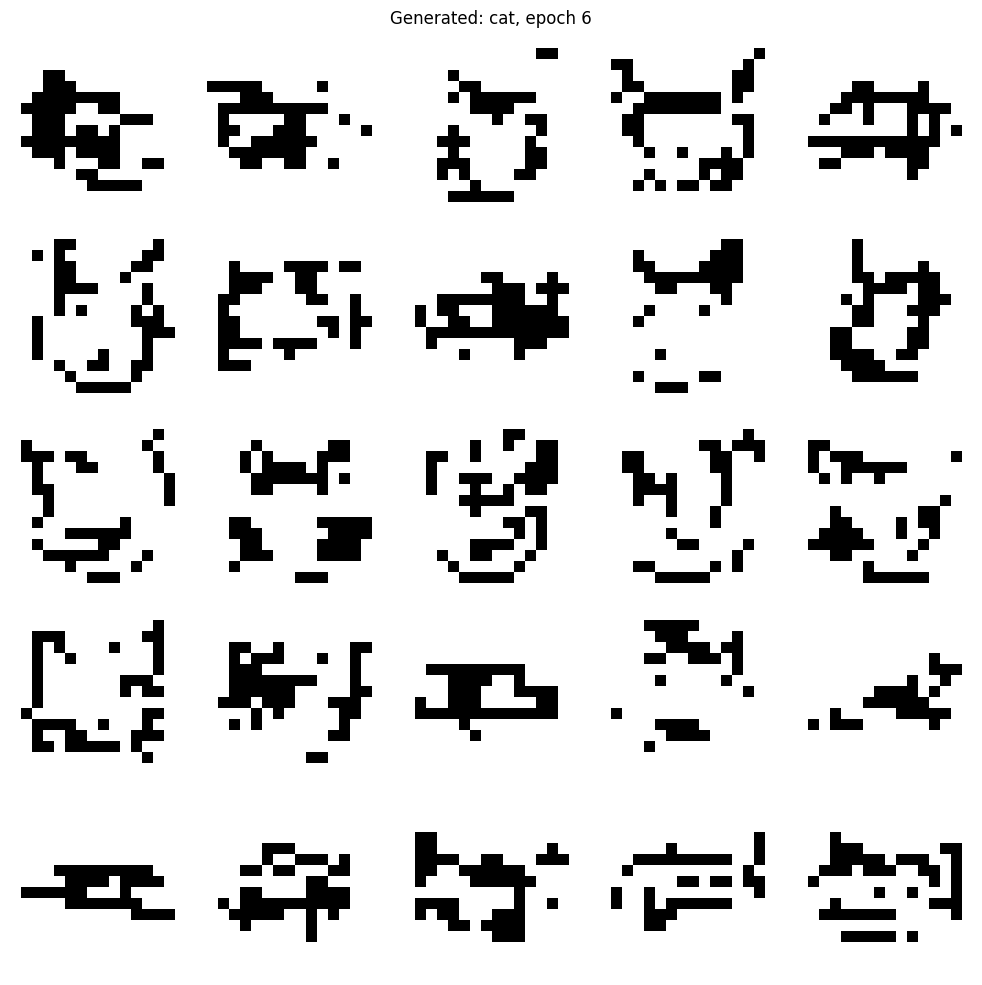


Epoch 7/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 7: train_loss=0.2882, val_loss=0.2862

Epoch 8/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 8: train_loss=0.2847, val_loss=0.2830


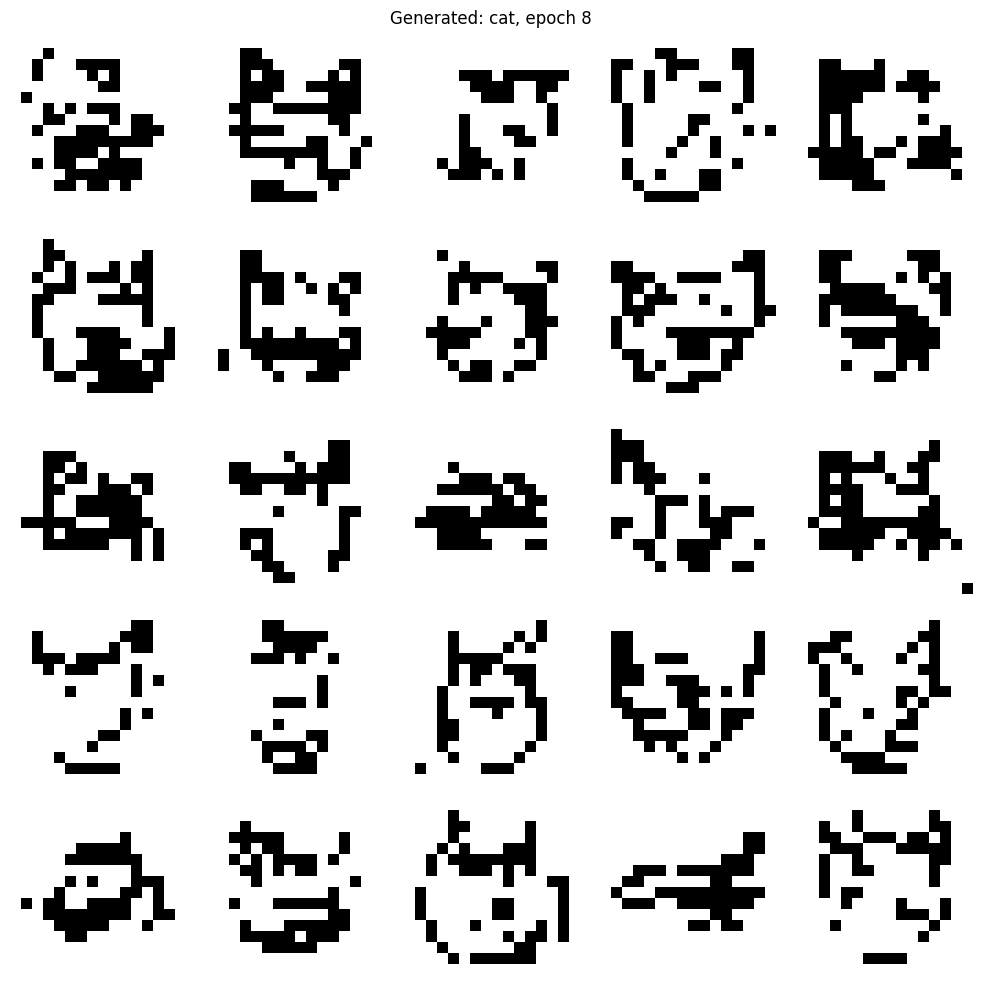


Epoch 9/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 9: train_loss=0.2825, val_loss=0.2816

Epoch 10/10


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/16 [00:00<?, ?it/s]

epoch 10: train_loss=0.2803, val_loss=0.2795


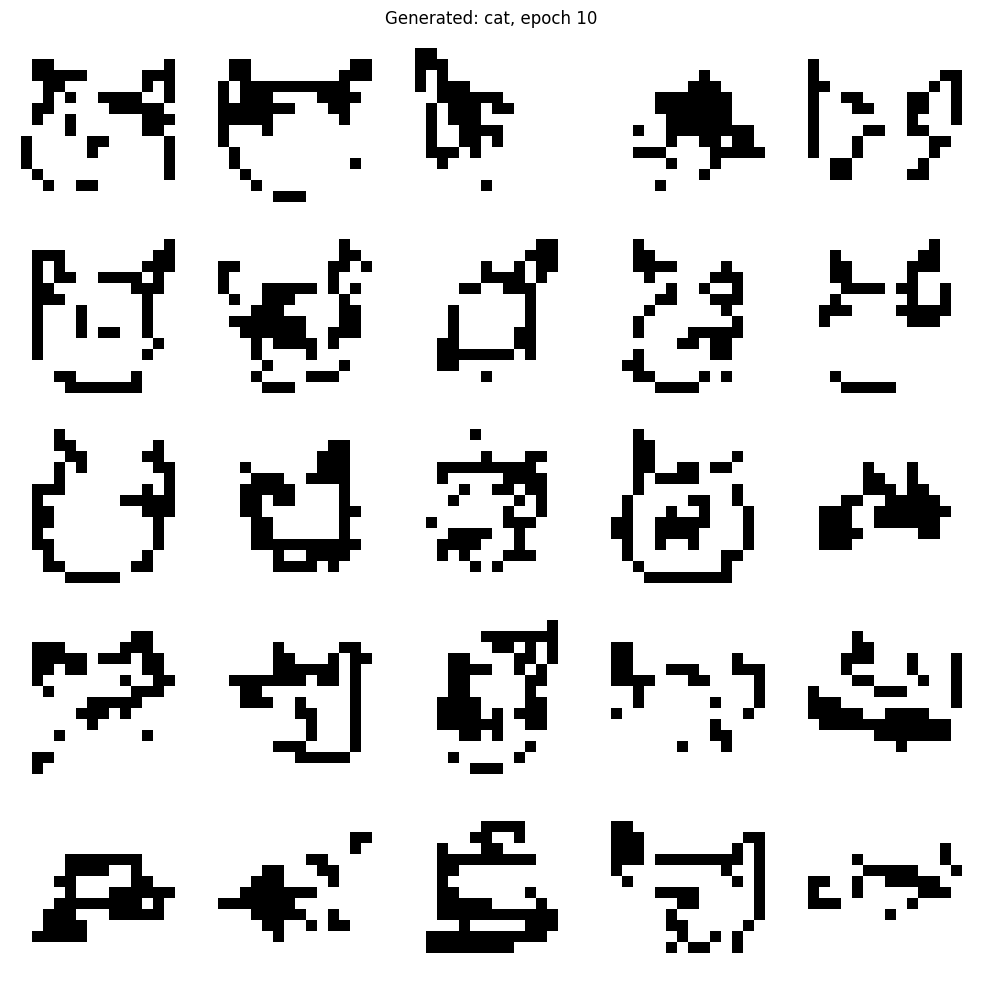

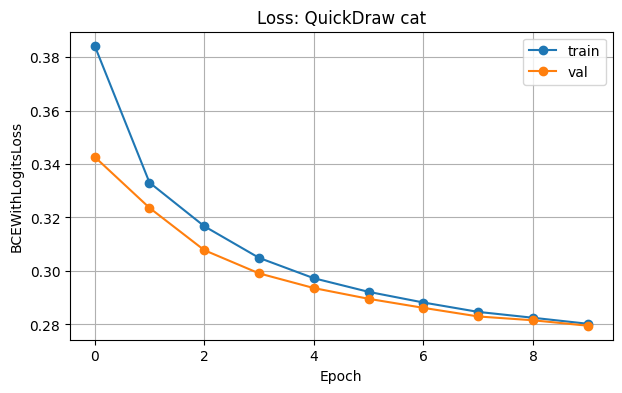

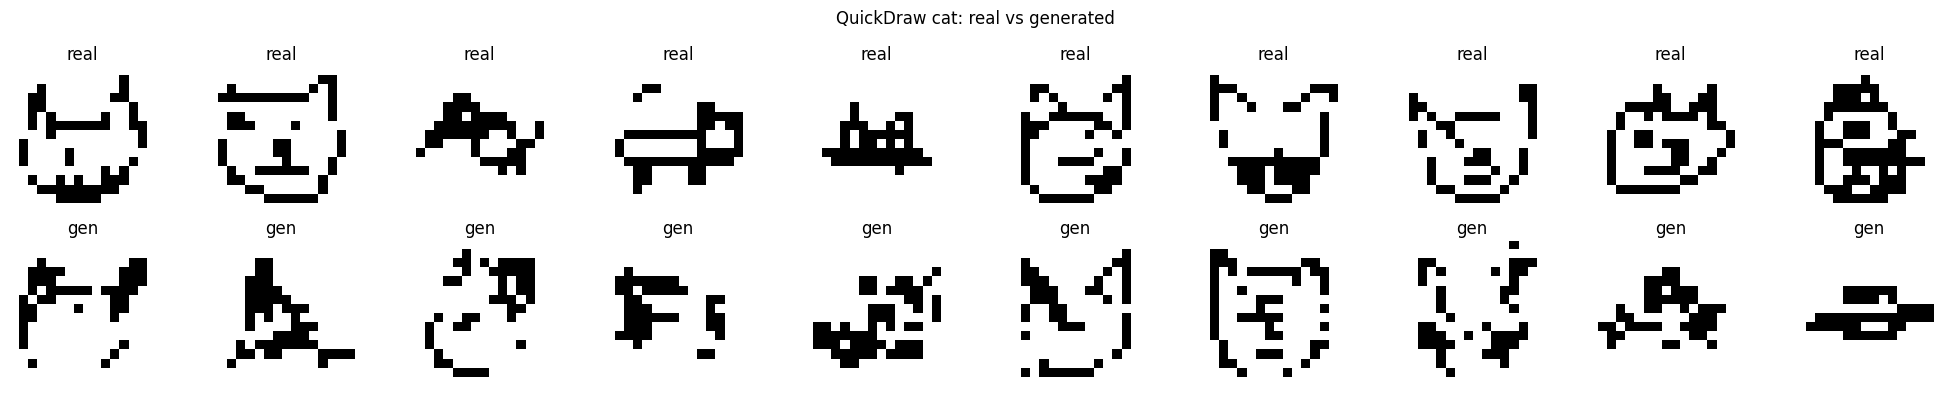

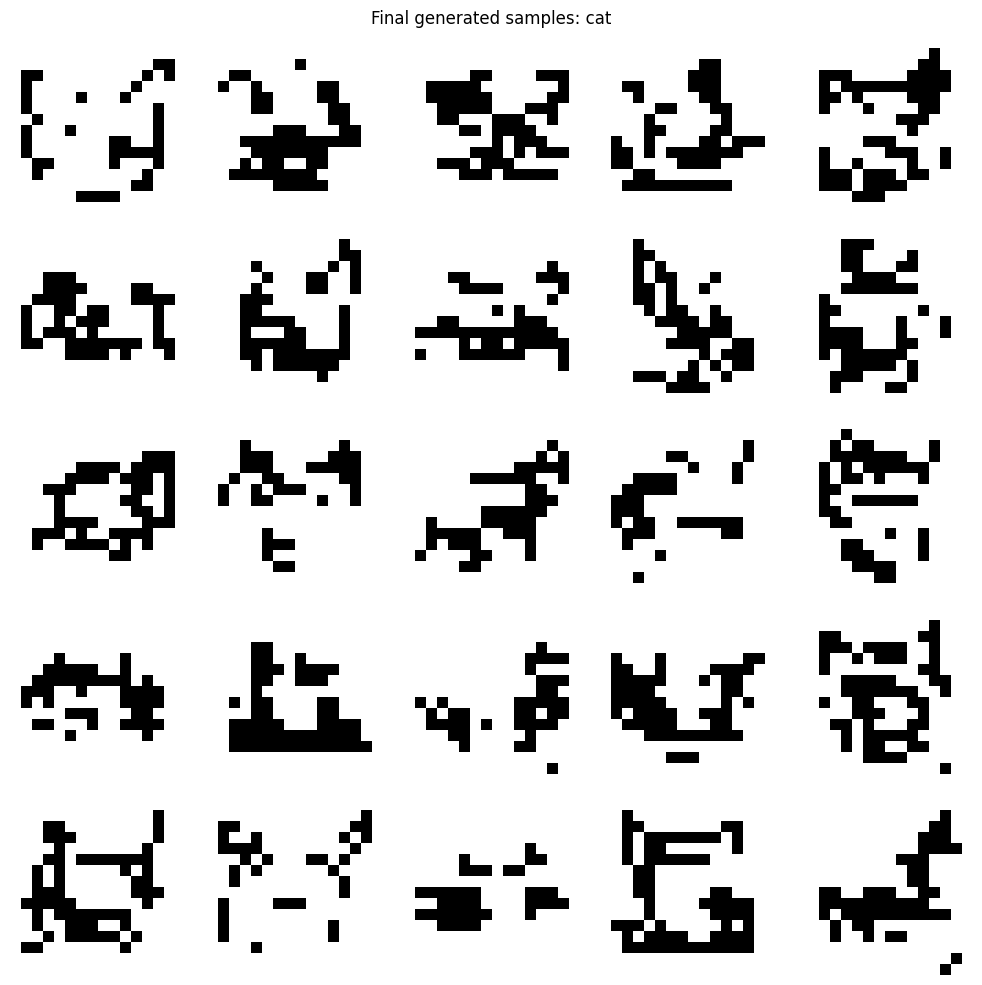

In [24]:
# ============================================================
# 8. Normal small experiment
# ============================================================

cat_result = run_experiment(
    category="cat",
    image_size=16,
    n_samples=10_000,
    batch_size=64,
    num_epochs=10,
    embed_dim=128,
    num_heads=4,
    num_layers=4,
    lr=3e-4,
    threshold=0.5,
    invert=True,
    show_every=2,
    num_workers=0,
)


Что то котики какие то страшные немного, но что то вырисовывается.

Experiment
category: banana
image_size: 16
n_samples: 5000
embed_dim: 128
num_heads: 4
num_layers: 4
Loaded dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 4500000
})
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle', 'binoculars', 'bird', 'birthday cake', 'blackberry', 'blueberry', 'book', 'boomerang', 'bottlecap', 'bowtie', 'bracelet', 'brain', 'bread', 'bridge', 'broccoli', 'broom', 'bucket', 'bulldozer', 'bus', 'bush', 'butterfly', 'cactus', 'cake', 'calculator', 'calendar', 'camel', 'camera', 'camouflage', 'campfire', 'candle', 'cannon', 'canoe', 'car', 'carrot', 'castle', 'cat', 'ceiling fan',

Filter:   0%|          | 0/4500000 [00:00<?, ? examples/s]

Final dataset size: 5000
First item keys: dict_keys(['image', 'label'])


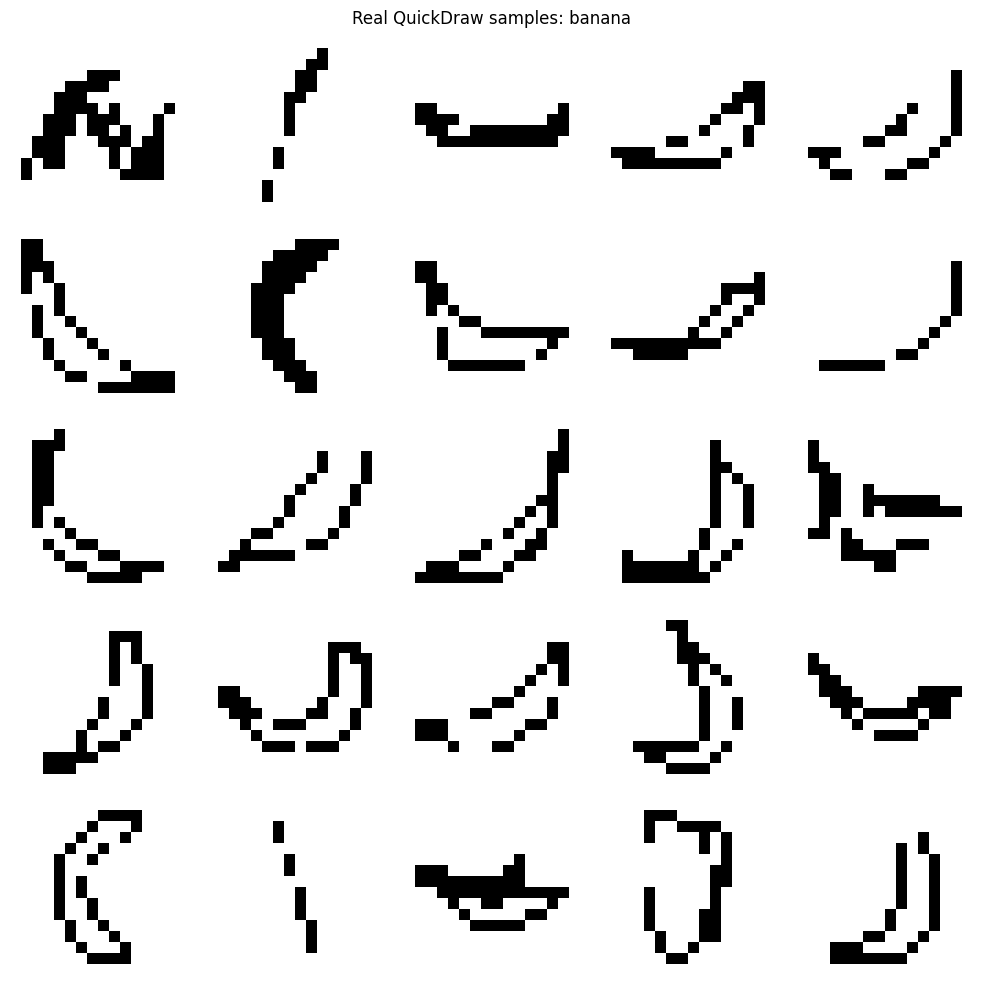


Epoch 1/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 1: train_loss=0.3346, val_loss=0.3138


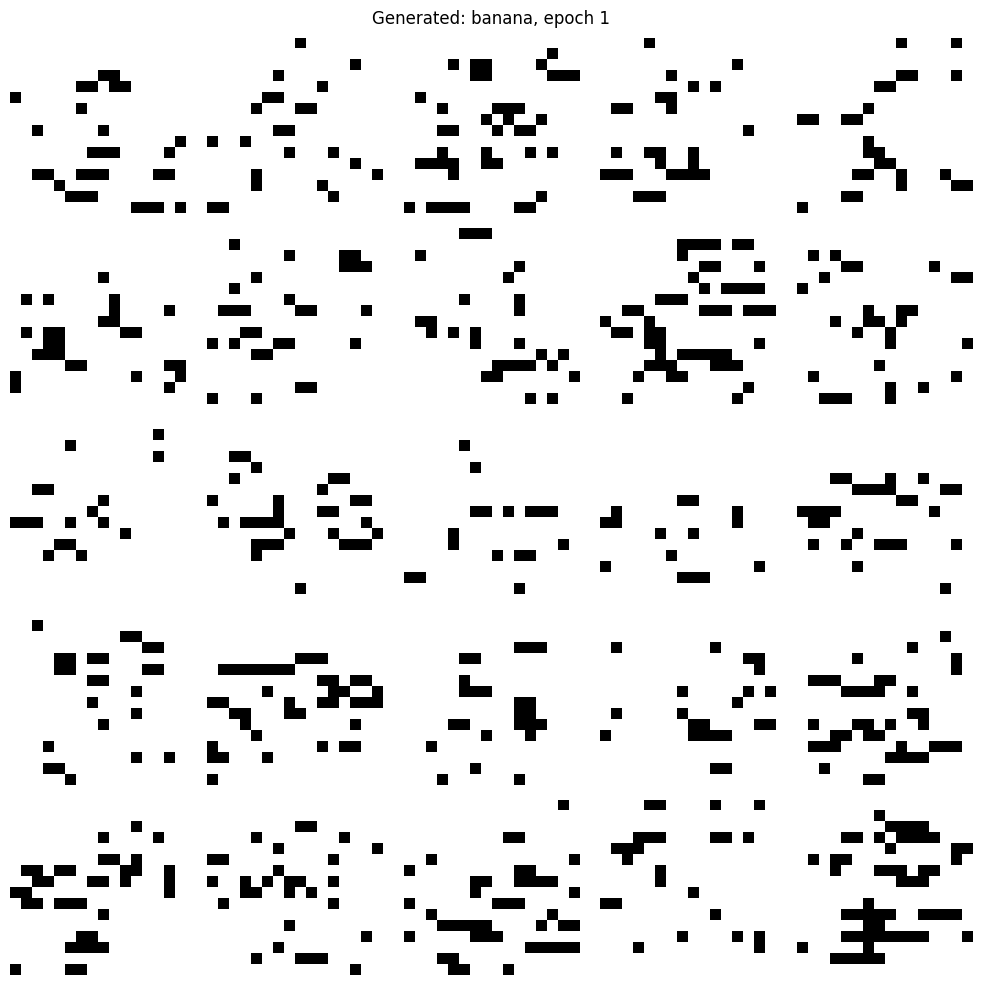


Epoch 2/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 2: train_loss=0.2929, val_loss=0.2696

Epoch 3/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

...

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 4: train_loss=0.2388, val_loss=0.2320

Epoch 5/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 5: train_loss=0.2276, val_loss=0.2227


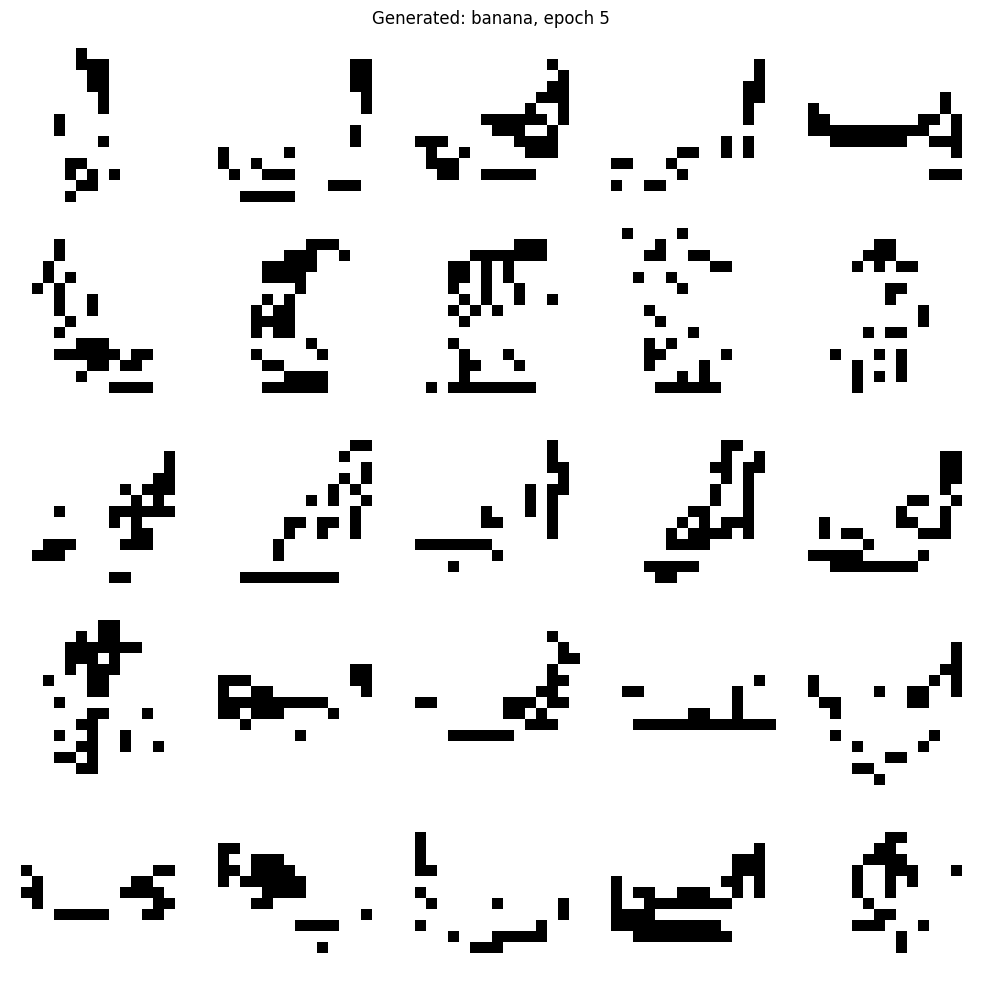

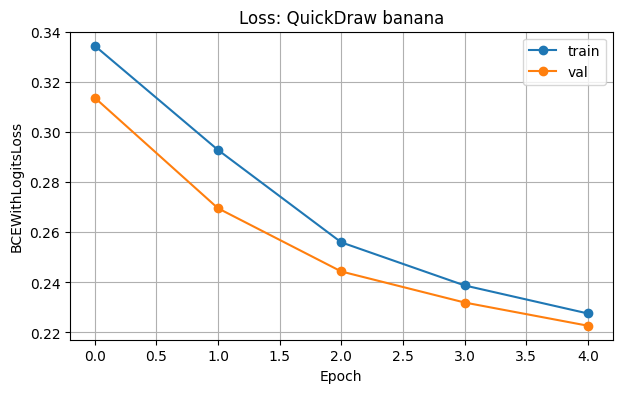

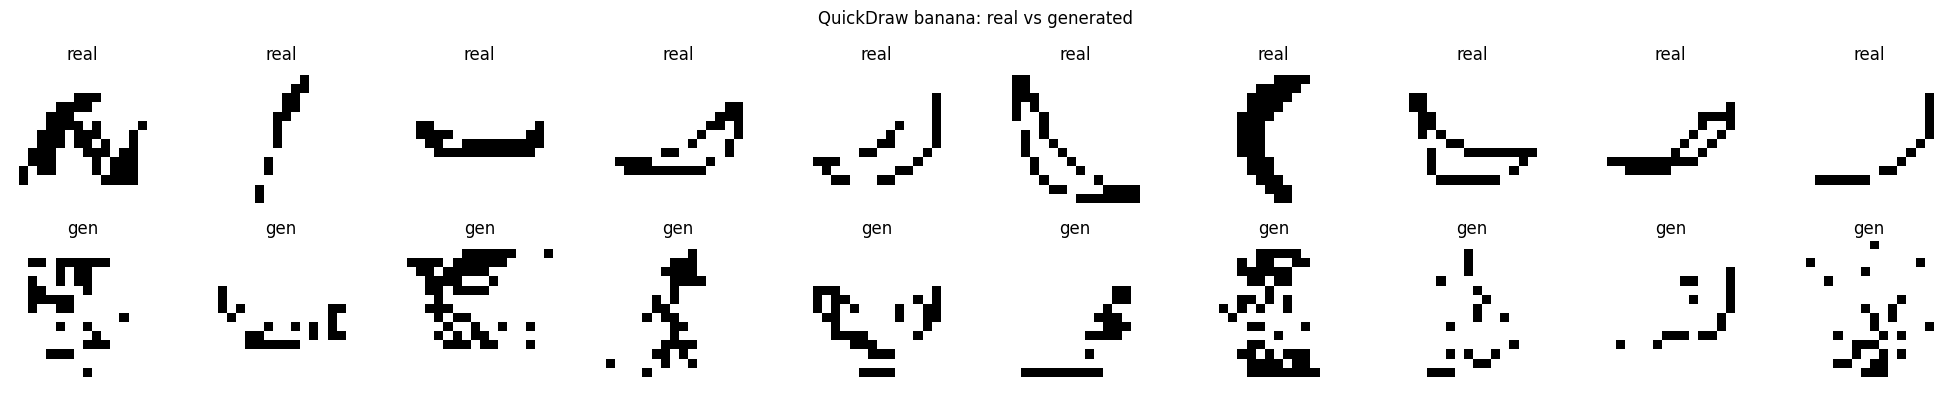

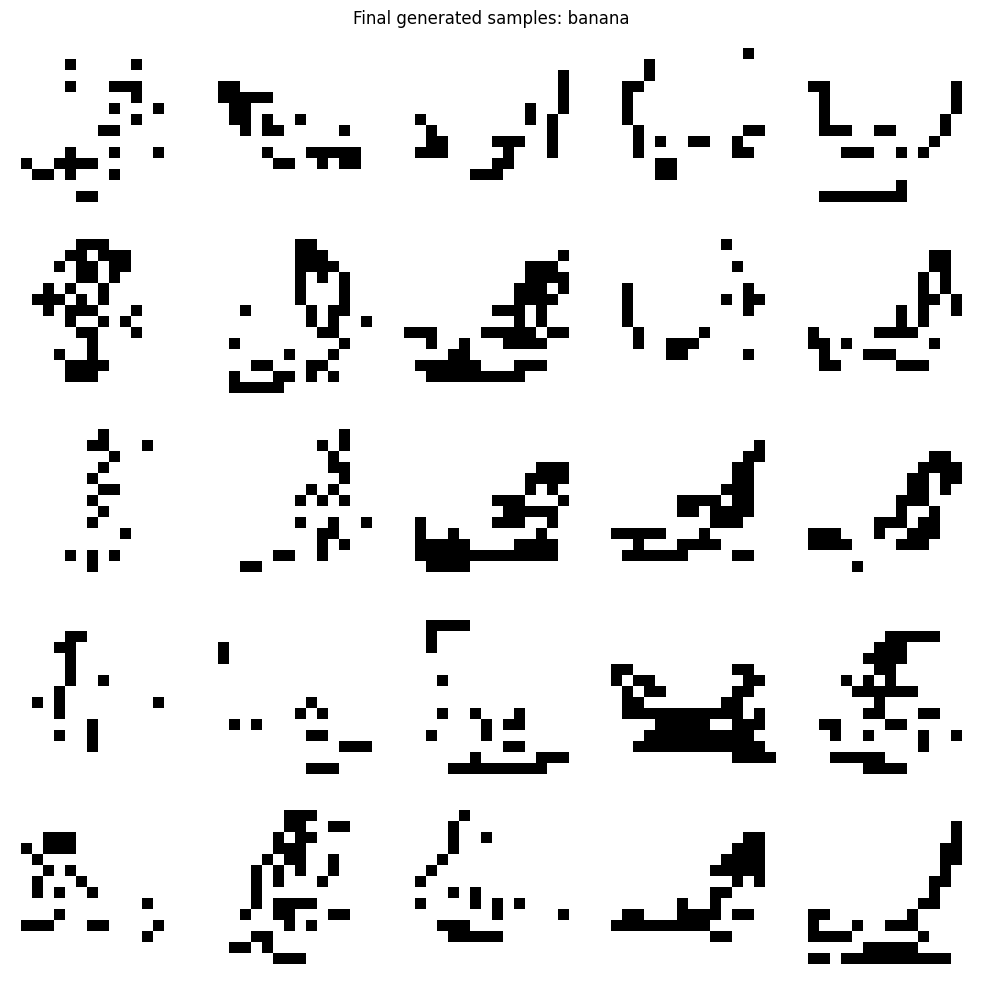

Experiment
category: house
image_size: 16
n_samples: 5000
embed_dim: 128
num_heads: 4
num_layers: 4
Loaded dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 4500000
})
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle', 'binoculars', 'bird', 'birthday cake', 'blackberry', 'blueberry', 'book', 'boomerang', 'bottlecap', 'bowtie', 'bracelet', 'brain', 'bread', 'bridge', 'broccoli', 'broom', 'bucket', 'bulldozer', 'bus', 'bush', 'butterfly', 'cactus', 'cake', 'calculator', 'calendar', 'camel', 'camera', 'camouflage', 'campfire', 'candle', 'cannon', 'canoe', 'car', 'carrot', 'castle', 'cat', 'ceiling fan', 

Filter:   0%|          | 0/4500000 [00:00<?, ? examples/s]

Final dataset size: 5000
First item keys: dict_keys(['image', 'label'])


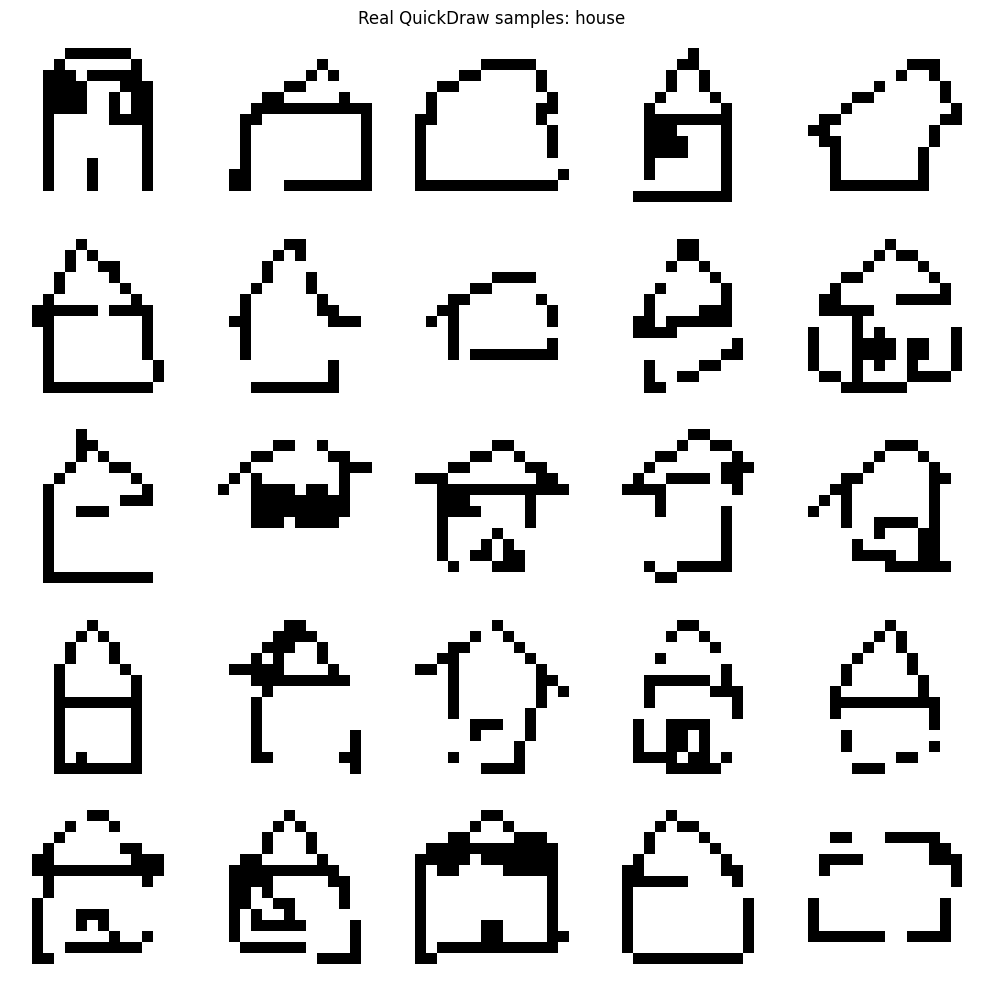


Epoch 1/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 1: train_loss=0.4092, val_loss=0.3608


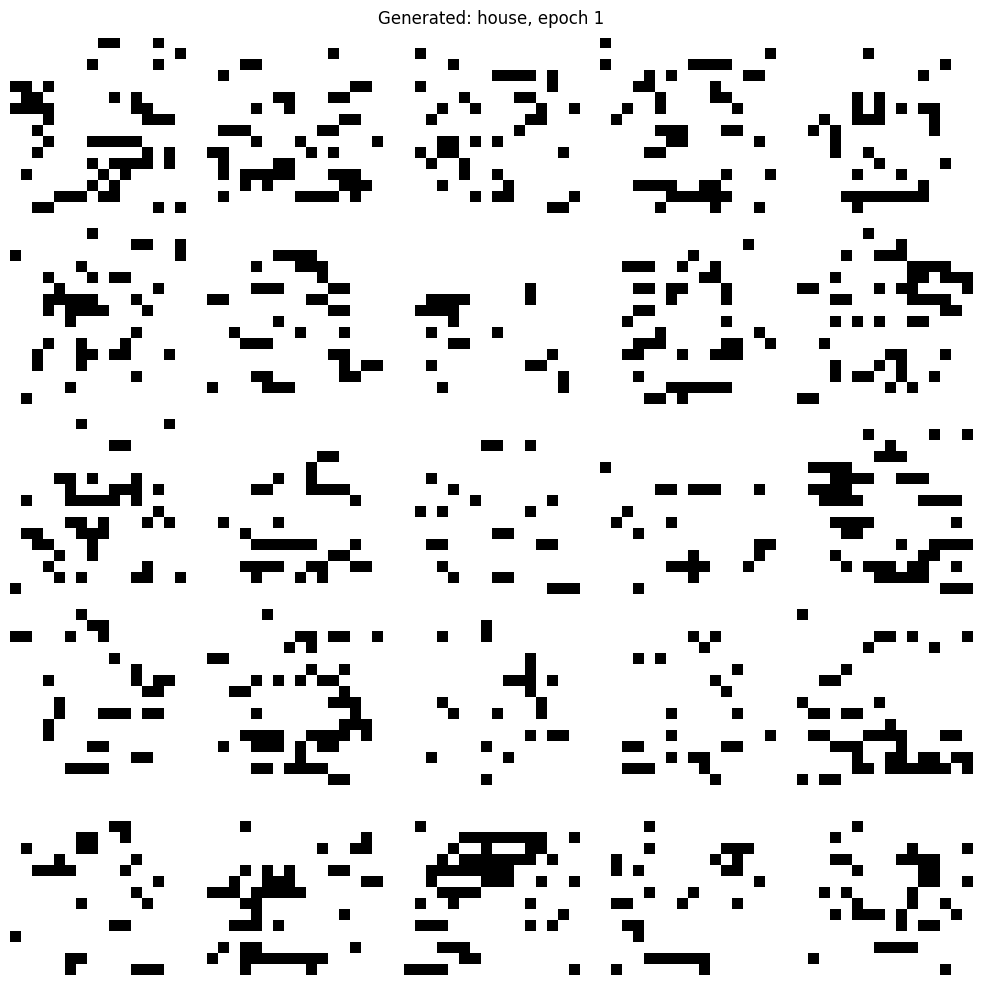


Epoch 2/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 2: train_loss=0.3313, val_loss=0.3034

Epoch 3/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

...

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 4: train_loss=0.2706, val_loss=0.2571

Epoch 5/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 5: train_loss=0.2519, val_loss=0.2425


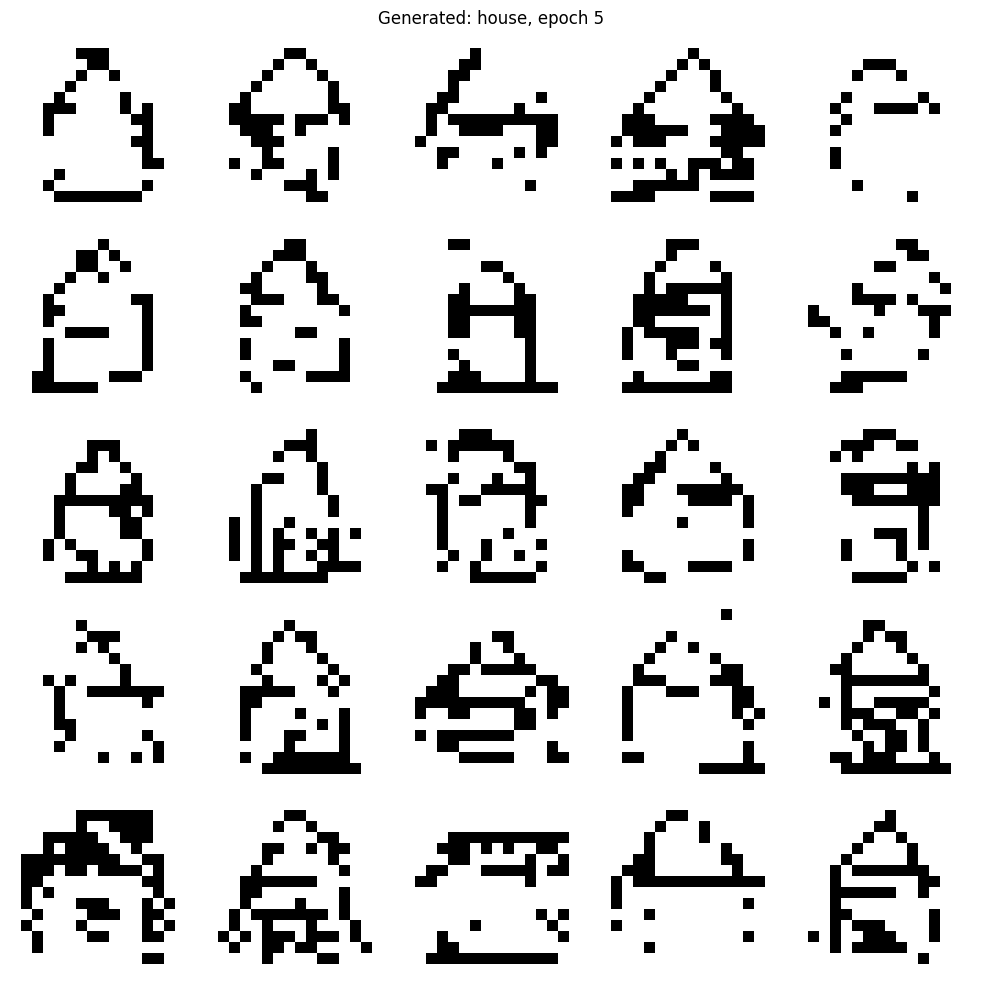

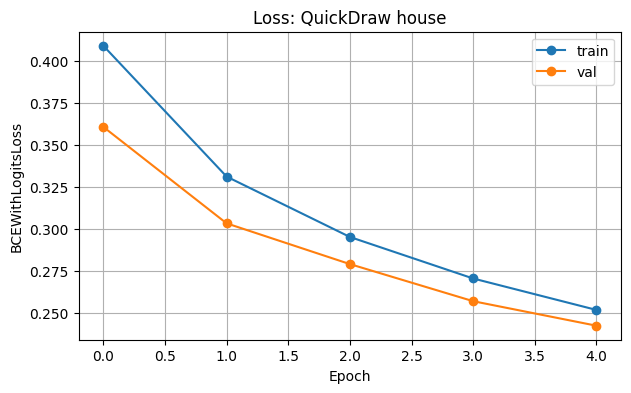

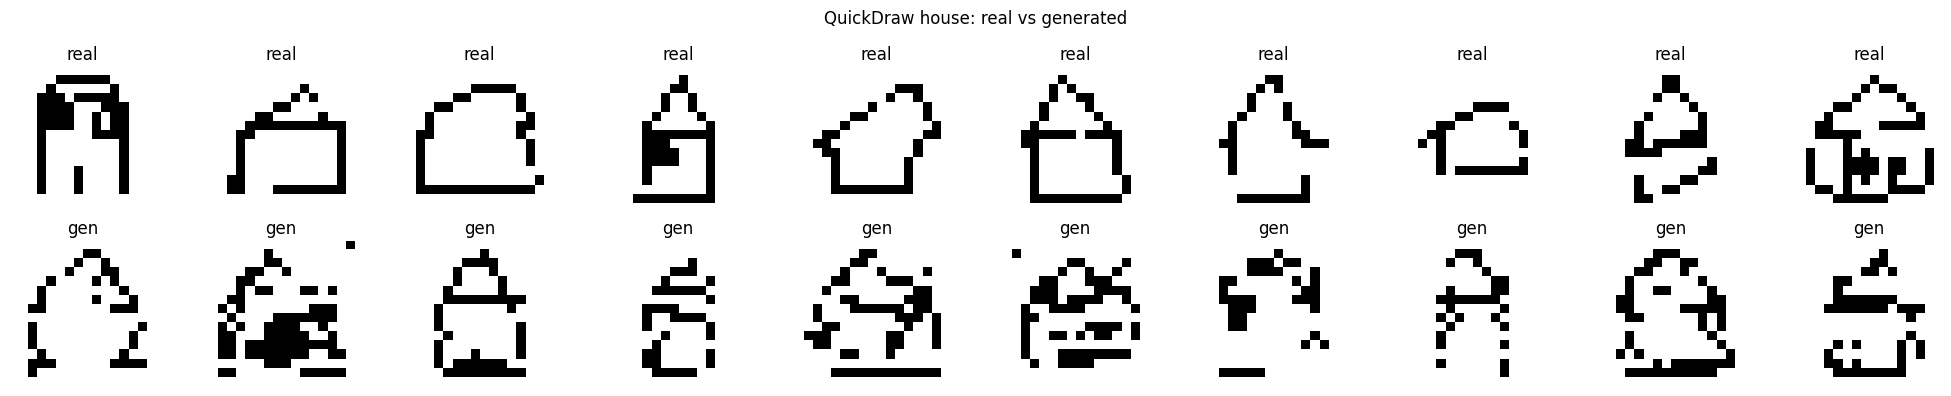

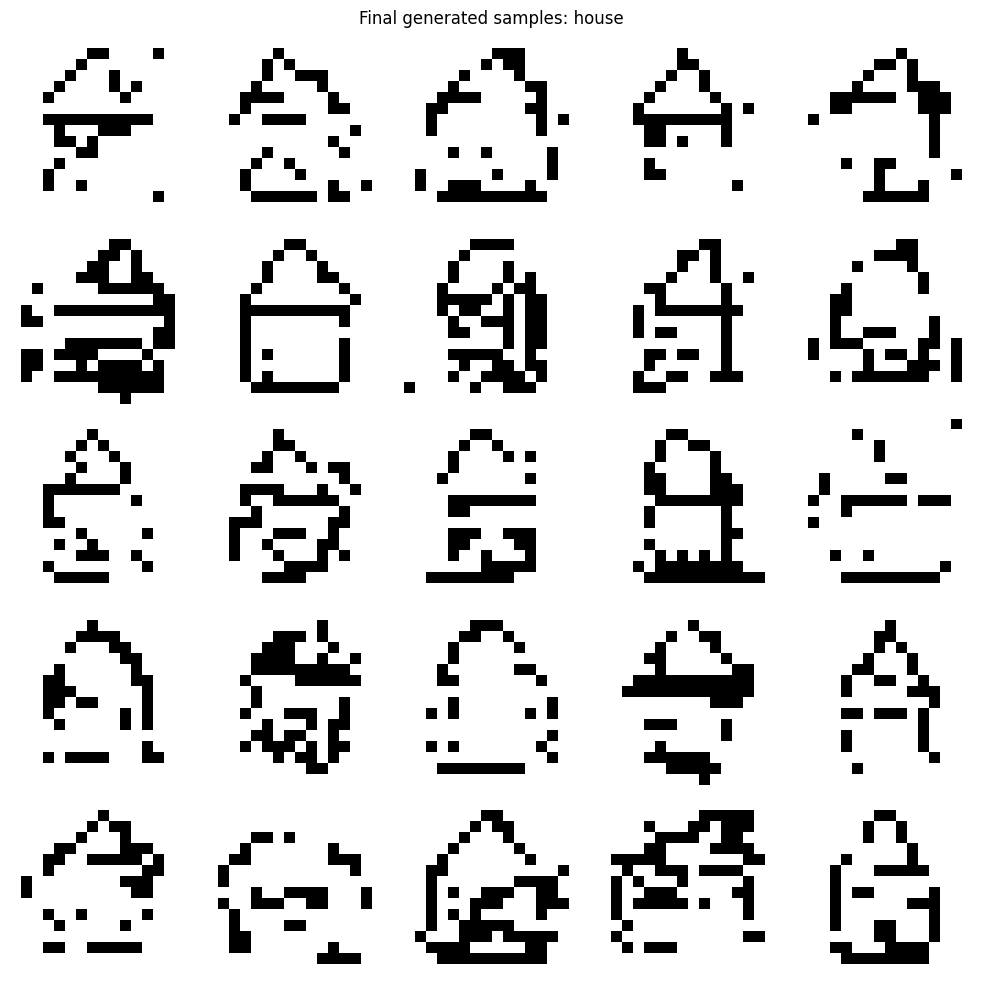

Experiment
category: tree
image_size: 16
n_samples: 5000
embed_dim: 128
num_heads: 4
num_layers: 4
Loaded dataset:
Dataset({
    features: ['image', 'label'],
    num_rows: 4500000
})
Columns: ['image', 'label']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['aircraft carrier', 'airplane', 'alarm clock', 'ambulance', 'angel', 'animal migration', 'ant', 'anvil', 'apple', 'arm', 'asparagus', 'axe', 'backpack', 'banana', 'bandage', 'barn', 'baseball bat', 'baseball', 'basket', 'basketball', 'bat', 'bathtub', 'beach', 'bear', 'beard', 'bed', 'bee', 'belt', 'bench', 'bicycle', 'binoculars', 'bird', 'birthday cake', 'blackberry', 'blueberry', 'book', 'boomerang', 'bottlecap', 'bowtie', 'bracelet', 'brain', 'bread', 'bridge', 'broccoli', 'broom', 'bucket', 'bulldozer', 'bus', 'bush', 'butterfly', 'cactus', 'cake', 'calculator', 'calendar', 'camel', 'camera', 'camouflage', 'campfire', 'candle', 'cannon', 'canoe', 'car', 'carrot', 'castle', 'cat', 'ceiling fan', '

Filter:   0%|          | 0/4500000 [00:00<?, ? examples/s]

Final dataset size: 5000
First item keys: dict_keys(['image', 'label'])


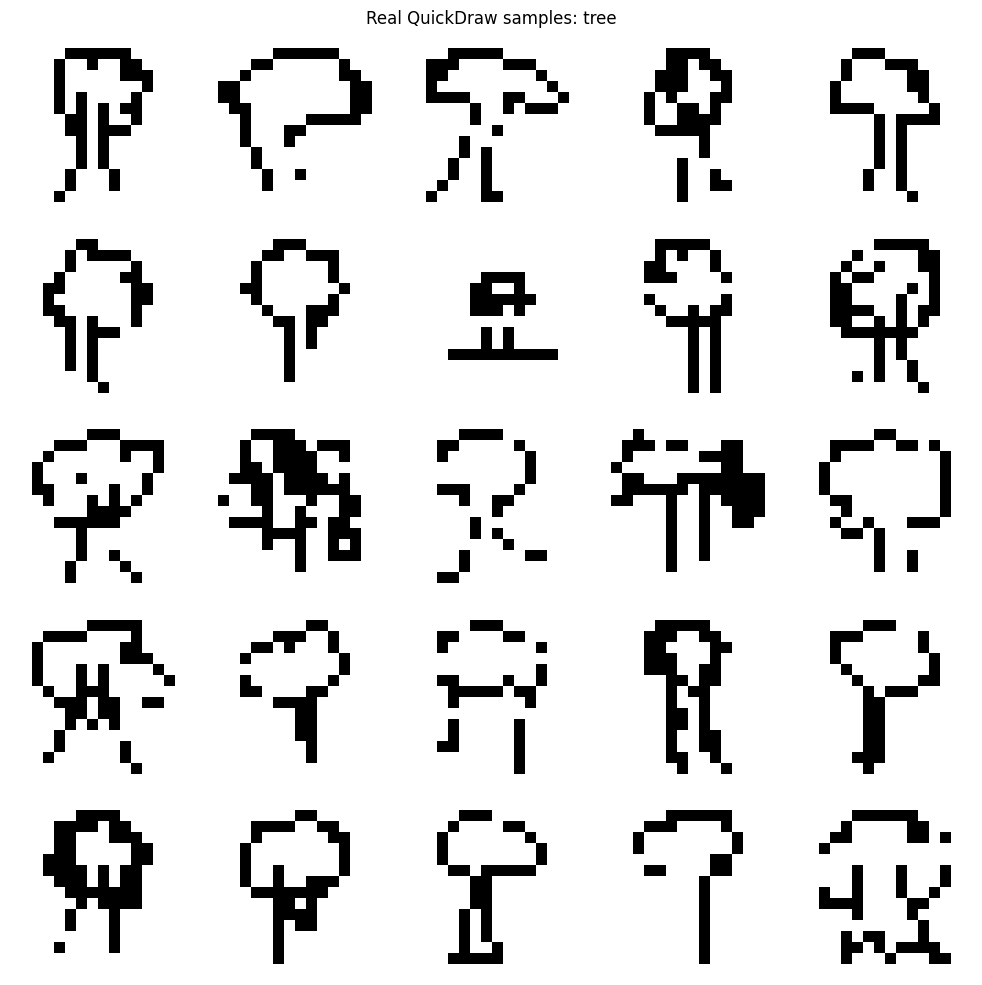


Epoch 1/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 1: train_loss=0.4145, val_loss=0.3587


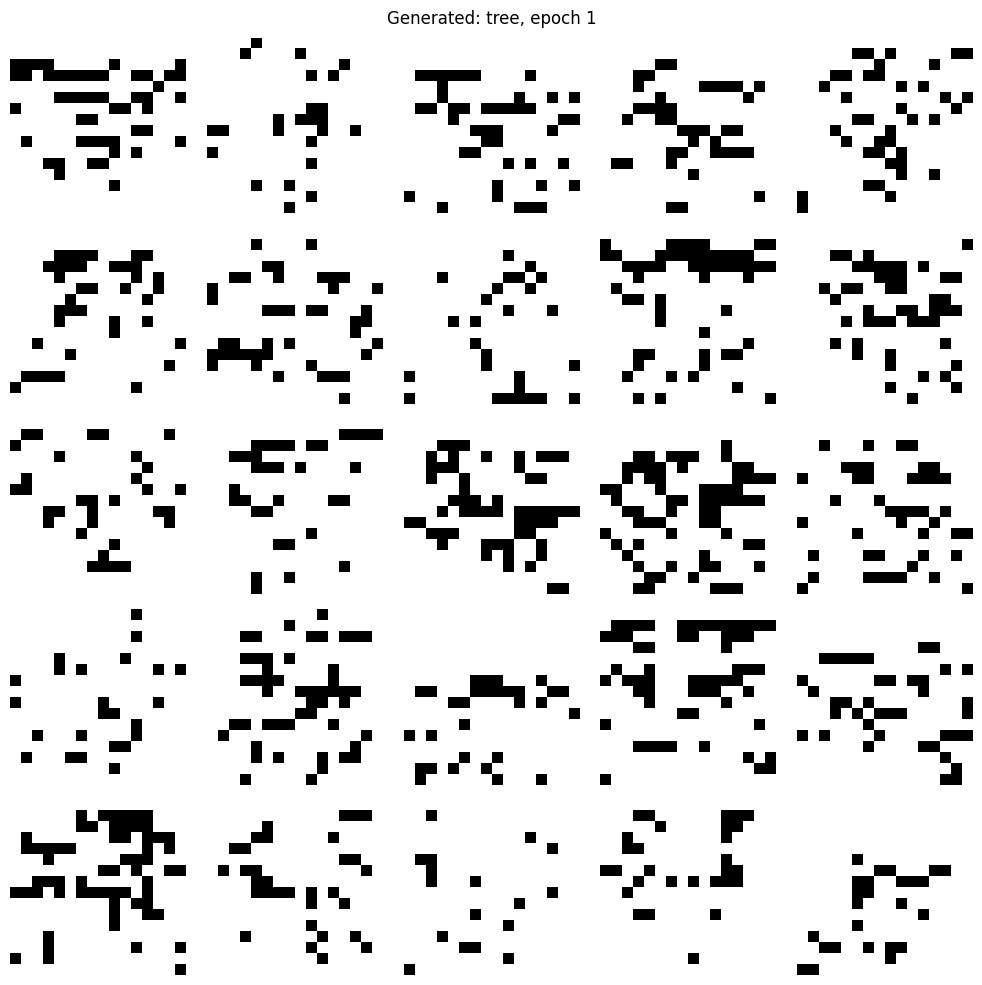


Epoch 2/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 2: train_loss=0.3263, val_loss=0.3137

Epoch 3/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

...

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 4: train_loss=0.2977, val_loss=0.2947

Epoch 5/5


train:   0%|          | 0/70 [00:00<?, ?it/s]

eval:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 5: train_loss=0.2874, val_loss=0.2835


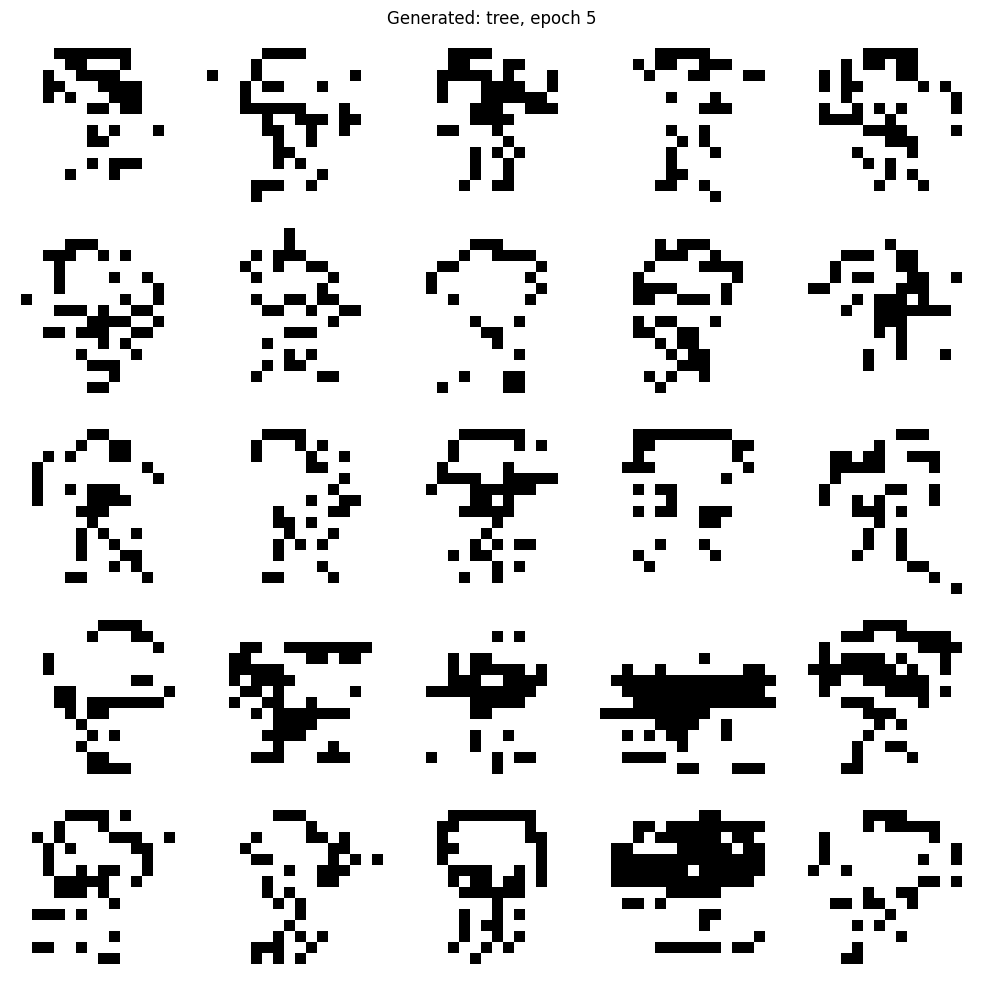

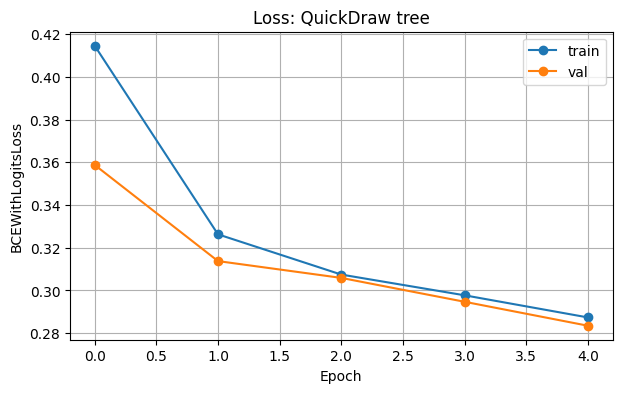

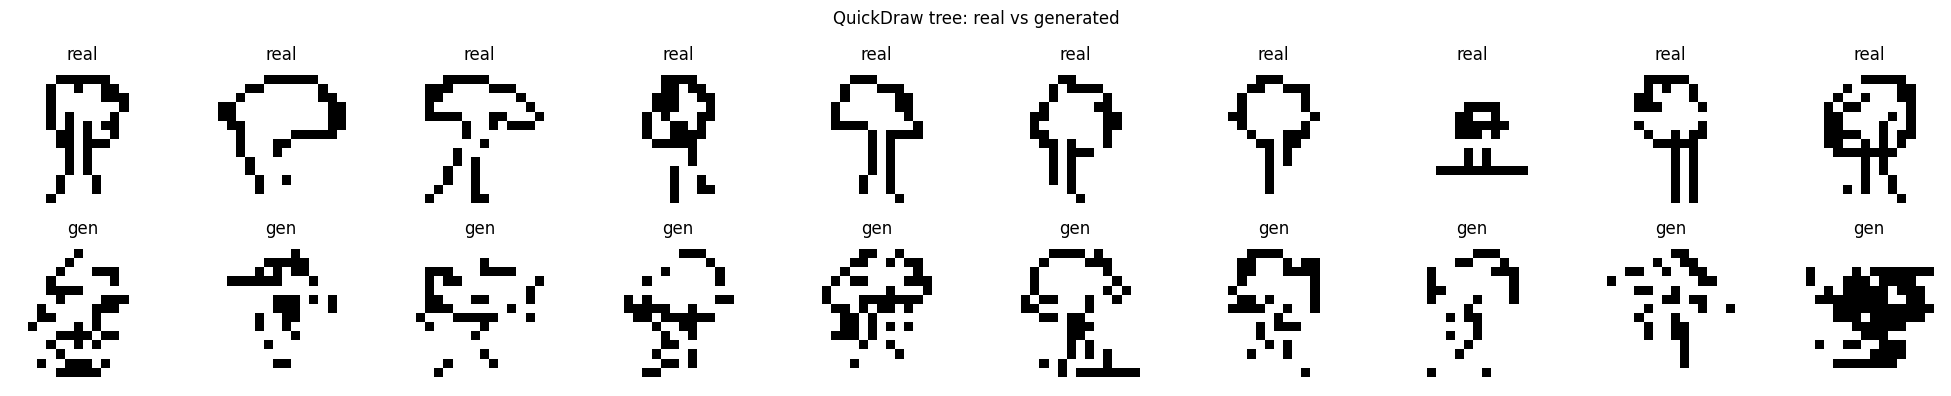

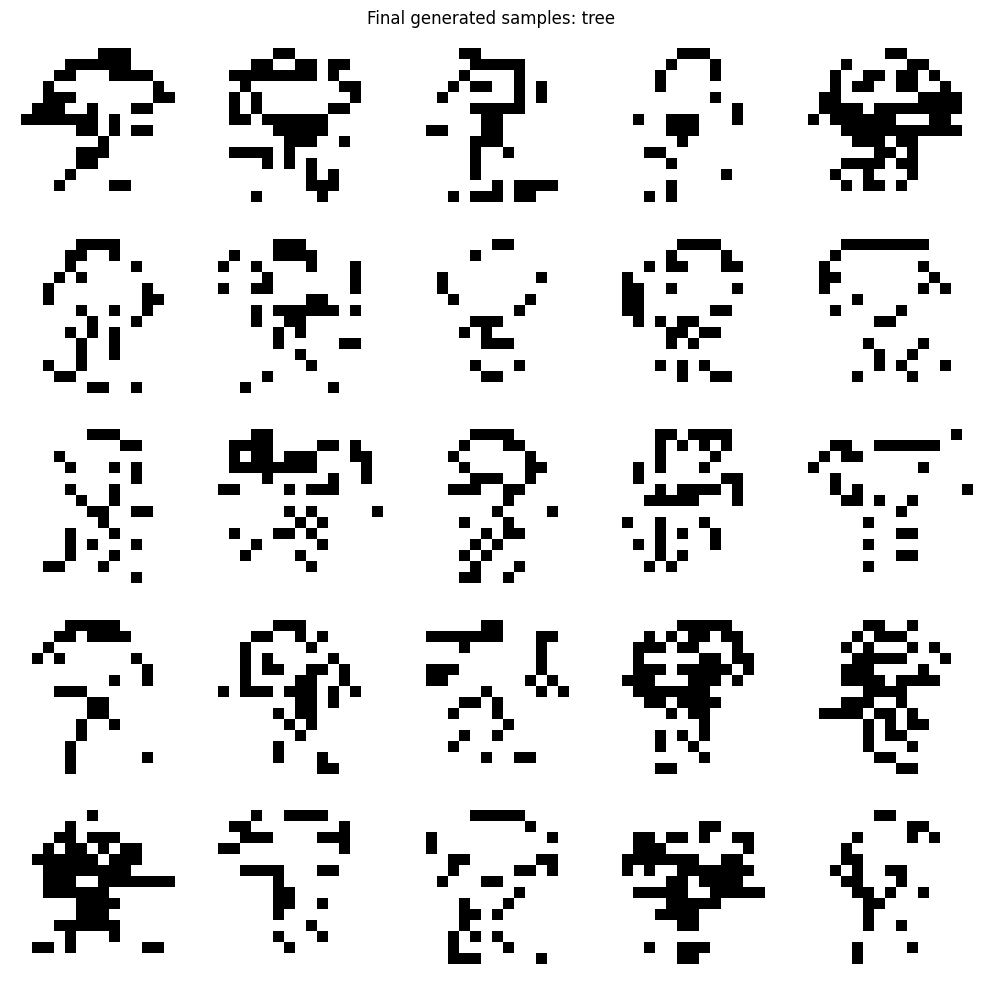

In [28]:
# ============================================================
# 9. Experiments with several categories
# ============================================================

categories = ["banana", "house", "tree"]

results = {}

for category in categories:
    results[category] = run_experiment(
        category=category,
        image_size=16,
        n_samples=5000,
        batch_size=64,
        num_epochs=5,
        embed_dim=128,
        num_heads=4,
        num_layers=4,
        lr=3e-4,
        threshold=0.5,
        invert=True,
        show_every=5,
        num_workers=0,
    )


Бананы обиженные какие то, домики вообще топчик, деревьям бы тоже еще поучиться.

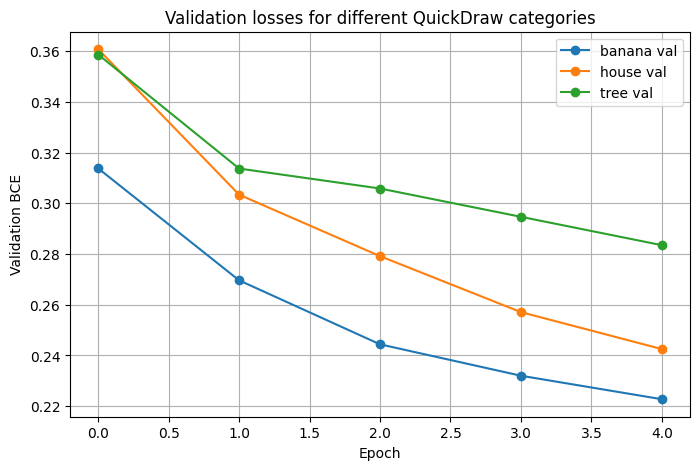

In [29]:
# ============================================================
# 10. Compare losses between experiments
# ============================================================

plt.figure(figsize=(8, 5))

for category, result in results.items():
    plt.plot(
        result["val_losses"],
        marker="o",
        label=f"{category} val",
    )

plt.xlabel("Epoch")
plt.ylabel("Validation BCE")
plt.title("Validation losses for different QuickDraw categories")
plt.grid(True)
plt.legend()
plt.show()


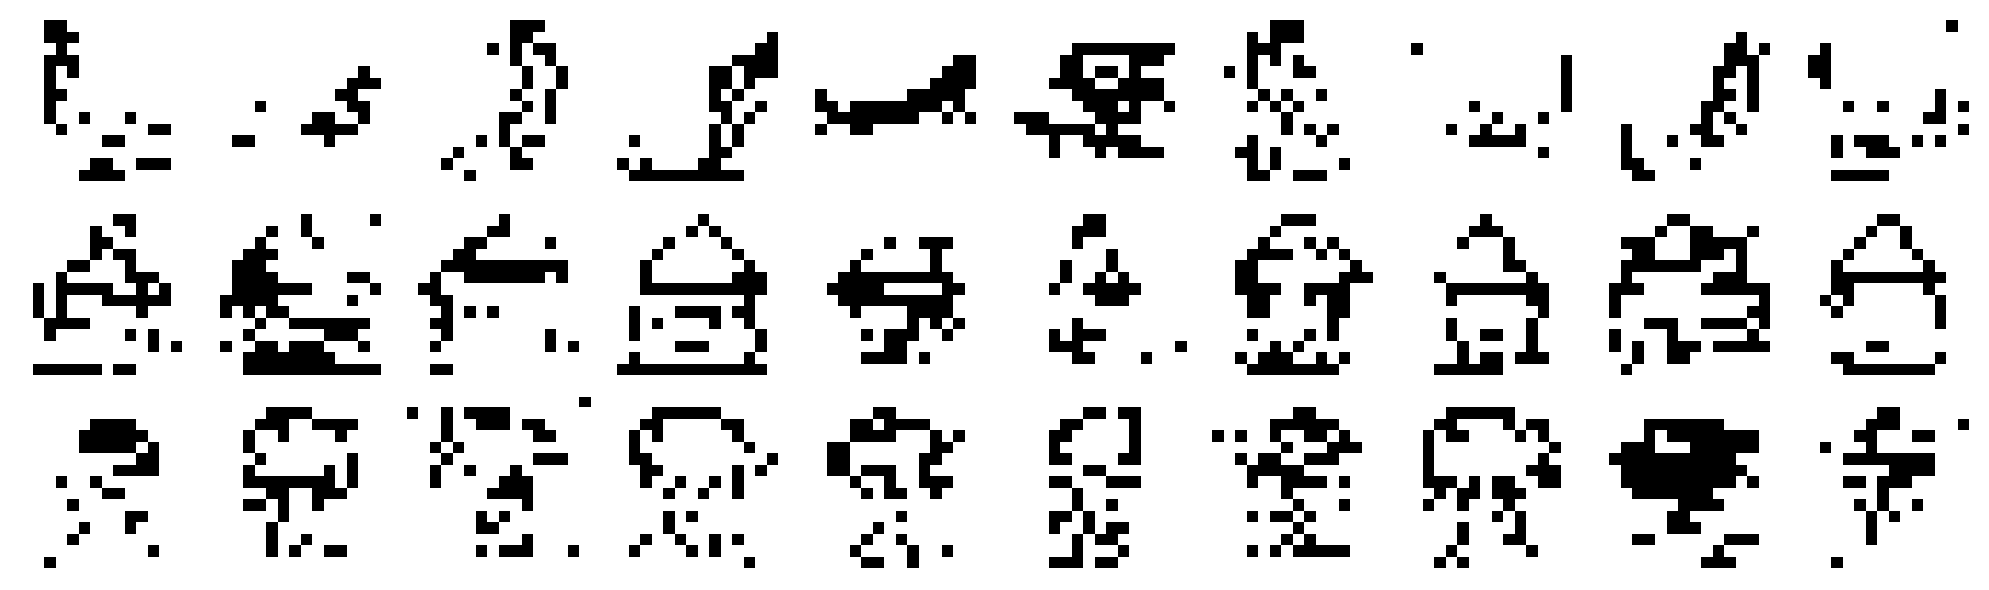

In [30]:
# ============================================================
# 11. Visual compare final samples from several models
# ============================================================

@torch.no_grad()
def show_multi_category_samples(
    results: dict,
    n_samples_per_category: int = 10,
) -> None:
    n_categories = len(results)

    fig, axes = plt.subplots(
        n_categories,
        n_samples_per_category,
        figsize=(2 * n_samples_per_category, 2 * n_categories),
    )

    if n_categories == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (category, result) in enumerate(results.items()):
        model = result["model"]
        model.eval()

        samples = model.sample(n_samples_per_category).detach().cpu()

        for col_idx in range(n_samples_per_category):
            axes[row_idx, col_idx].imshow(
                samples[col_idx, 0],
                cmap="gray",
                vmin=0,
                vmax=1,
            )
            axes[row_idx, col_idx].axis("off")

            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(category)

    plt.tight_layout()
    plt.show()


show_multi_category_samples(results, n_samples_per_category=10)
